# Lab 5B – Symulacja VAR(1) i estymatory HC

Celem jest zbadanie przydatności estymatorów heteroskedastycznie zgodnych (HC)
przy estymacji modelu VAR i badaniu przyczynowości w sensie Grangera.

W szczególności:

- dane generujemy z modelu VAR(1),
- przyjmujemy brak przyczynowości (γ₁ = δ₁ = 0),
- estymujemy model klasycznym OLS oraz z wykorzystaniem różnych estymatorów HC,
- analizujemy rozkład estymatorów parametrów oraz rozmiar testów (w tym testu
  przyczynowości od Y_t do X_t).


In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm
from statsmodels.tsa.api import VAR
import matplotlib.pyplot as plt

import warnings

warnings.filterwarnings("ignore")
SEED = 42

np.random.seed(SEED)

# Parametry DGP VAR(1) (stałe w wszystkich scenariuszach)
ALPHA_X = 1.0
ALPHA_Y = 1.0
GAMMA_1 = 0.0  # brak przyczynowości Y -> X
DELTA_1 = 0.0  # brak przyczynowości X -> Y
SIGMA = 1.0

# Siatka wartości parametrów autokorelacji w X_t i Y_t (4 scenariusze)
BETA_VALUES = [-0.7, 0.7]
THETA_VALUES = [-0.7, 0.7]
PARAM_GRID = [(b, t) for b in BETA_VALUES for t in THETA_VALUES]

# Dla części ilustracyjnej (pojedyncza realizacja / wybór rzędu VAR)
# korzystamy z referencyjnego zestawu parametrów, np. (0.7, 0.7).
BETA_1 = 0.7  # autokorelacja X_t w przykładzie ilustrującym
THETA_1 = 0.7  # autokorelacja Y_t w przykładzie ilustrującym

# Ustawienia symulacji
T = 200  # długość próby użytej do estymacji
BURNIN = 100  # dodatkowe obserwacje do rozgrzania procesu
N_SIM = 1000  # liczba replikacji Monte Carlo na każdy scenariusz (beta_1, theta_1)
ALPHA = 0.05  # poziom istotności testów

# Rodzaje estymatorów kowariancji: klasyczny i różne HC
HC_TYPES = ["classic", "HC0", "HC1", "HC2", "HC3"]


In [2]:
def simulate_var1(
    T,
    alpha_x,
    alpha_y,
    beta_1,
    gamma_1,
    delta_1,
    theta_1,
    sigma,
    burnin=100,
    rng=None,
):
    """
    Symuluje dane z dwuwymiarowego VAR(1):
        X_t = α_x + β_1 X_{t-1} + γ_1 Y_{t-1} + ε_t
        Y_t = α_y + δ_1 X_{t-1} + θ_1 Y_{t-1} + η_t
    gdzie [ε_t, η_t]' ~ N(0, σ^2 I).

    Zwraca DataFrame z kolumnami 'X', 'Y' o długości T.
    """
    if rng is None:
        rng = np.random.default_rng()

    n_total = T + burnin
    shocks = rng.normal(loc=0.0, scale=sigma, size=(n_total, 2))

    x = np.zeros(n_total)
    y = np.zeros(n_total)

    for t in range(1, n_total):
        x[t] = (
            alpha_x
            + beta_1 * x[t - 1]
            + gamma_1 * y[t - 1]
            + shocks[t, 0]
        )
        y[t] = (
            alpha_y
            + delta_1 * x[t - 1]
            + theta_1 * y[t - 1]
            + shocks[t, 1]
        )

    df = pd.DataFrame({"X": x[burnin:], "Y": y[burnin:]})
    return df


In [3]:
def build_regressions_var1(df):
    """
    Dla danych (X_t, Y_t) buduje macierze regresyjne dla dwóch równań VAR(1):

    X_t = α_x + β_1 X_{t-1} + γ_1 Y_{t-1} + ε_t
    Y_t = α_y + δ_1 X_{t-1} + θ_1 Y_{t-1} + η_t

    Zwraca: y_x, X_x, y_y, X_y.
    """
    df_lag = df.shift(1).dropna()

    # Po przesunięciu, pierwsza obserwacja jest utracona
    y_x = df["X"].iloc[1:]
    y_y = df["Y"].iloc[1:]

    X_lags = df_lag[["X", "Y"]].copy()
    X_lags.columns = ["X_lag", "Y_lag"]

    X_x = sm.add_constant(X_lags)
    X_y = sm.add_constant(X_lags)
    

    return y_x, X_x, y_y, X_y


In [4]:
# Jedna przykładowa realizacja i wybór rzędu VAR na podstawie
# trzech kryteriów informacyjnych (to część z 5A, tu beta i theta są równe 0.7)

rng = np.random.default_rng(SEED)
df_example = simulate_var1(
    T=T,
    alpha_x=ALPHA_X,
    alpha_y=ALPHA_Y,
    beta_1=BETA_1,
    gamma_1=GAMMA_1,
    delta_1=DELTA_1,
    theta_1=THETA_1,
    sigma=SIGMA,
    burnin=BURNIN,
    rng=rng,
)

model_example = VAR(df_example)
max_lags = 5
order_selection = model_example.select_order(maxlags=max_lags)
print("Wyniki wyboru rzędu VAR:")
print(order_selection.summary())


Wyniki wyboru rzędu VAR:
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0       1.057       1.090       2.877       1.070
1    0.07333*     0.1740*      1.076*     0.1141*
2      0.1021      0.2699       1.107      0.1700
3      0.1419      0.3769       1.152      0.2370
4      0.1678      0.4699       1.183      0.2901
5      0.1510      0.5203       1.163      0.3005
-------------------------------------------------


In [5]:
# Jedna przykładowa realizacja i wybór rzędu VAR na podstawie
# trzech kryteriów informacyjnych dla 4 możliwych kombinacji wartości beta i theta

rng = np.random.default_rng(SEED)
max_lags = 5

print(f"{'='*60}")
print(f"Wybór rzędu opóźnień (max_lags={max_lags}) dla 4 scenariuszy")
print(f"{'='*60}\n")

for beta, theta in PARAM_GRID:
    # Symulacja danych dla konkretnej pary (beta, theta) ze siatki parametrów
    df_example = simulate_var1(
        T=T,
        alpha_x=ALPHA_X,
        alpha_y=ALPHA_Y,
        beta_1=beta,       # Używamy wartości z pętli
        gamma_1=GAMMA_1,
        delta_1=DELTA_1,
        theta_1=theta,     # Używamy wartości z pętli
        sigma=SIGMA,
        burnin=BURNIN,
        rng=rng,
    )

    # Inicjalizacja modelu VAR na symulowanych danych
    model_example = VAR(df_example)
    
    # Wybór rzędu na podstawie kryteriów informacyjnych
    order_selection = model_example.select_order(maxlags=max_lags)

    # Wyświetlenie wyników dla danego scenariusza
    print(f"--- Scenariusz: beta_1 = {beta}, theta_1 = {theta} ---")
    print(order_selection.summary())
    print("\n")

Wybór rzędu opóźnień (max_lags=5) dla 4 scenariuszy

--- Scenariusz: beta_1 = -0.7, theta_1 = -0.7 ---
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0       1.479       1.512       4.388       1.493
1     0.1036*     0.2044*      1.109*     0.1444*
2      0.1362      0.3041       1.146      0.2042
3      0.1597      0.3947       1.173      0.2549
4      0.1796      0.4817       1.197      0.3019
5      0.1772      0.5465       1.194      0.3267
-------------------------------------------------


--- Scenariusz: beta_1 = -0.7, theta_1 = 0.7 ---
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0       1.401       1.435       4.060       1.415
1   -0.01281*    0.08790*     0.9873*    0.02797*
2    -0.01186      0.1560      0.9882     0.05609
3     0.01339      0.2484       1.014      0.1

In [52]:
# Przykładowa estymacja równania dla X_t klasycznym OLS oraz
# z wykorzystaniem różnych estymatorów HC.

y_x, X_x, y_y, X_y = build_regressions_var1(df_example)

ols_x = sm.OLS(y_x, X_x).fit()
ols_y = sm.OLS(y_y, X_y).fit()

print("Równanie dla X_t – klasyczne odchylenia standardowe:")
print(ols_x.summary())

for cov_type in ["HC0", "HC1", "HC2", "HC3"]:
    rob_x = ols_x.get_robustcov_results(cov_type=cov_type)
    print(f"\nRównanie dla X_t – estymator {cov_type}:")
    print(rob_x.summary())


Równanie dla X_t – klasyczne odchylenia standardowe:
                            OLS Regression Results                            
Dep. Variable:                      X   R-squared:                       0.485
Model:                            OLS   Adj. R-squared:                  0.480
Method:                 Least Squares   F-statistic:                     92.39
Date:                Sun, 07 Dec 2025   Prob (F-statistic):           5.44e-29
Time:                        20:16:48   Log-Likelihood:                -289.60
No. Observations:                 199   AIC:                             585.2
Df Residuals:                     196   BIC:                             595.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

In [6]:
# Pętla Monte Carlo: estymatory parametrów i p-value dla klasycznych
# oraz HC-odpornych odchyleń standardowych, dla wszystkich scenariuszy (beta_1, theta_1).

base_rng = np.random.default_rng(SEED)

def p_value_for_param(beta_hat, beta_true, se, df_resid):
    t_stat = (beta_hat - beta_true) / se
    return 2 * stats.t.sf(np.abs(t_stat), df=df_resid)

# Struktury do przechowywania wyników: kluczem jest para parametrów (beta_1, theta_1).
all_estimates = {}
all_pvalues = {}
all_causality_rejects = {}  # test Y -> X (γ_1 = 0)

for beta_1, theta_1 in PARAM_GRID:
    true_params = {
        "alpha_x": ALPHA_X,
        "beta_1": beta_1,
        "gamma_1": GAMMA_1,
        "alpha_y": ALPHA_Y,
        "delta_1": DELTA_1,
        "theta_1": theta_1,
    }

    estimates = {hc: [] for hc in HC_TYPES}
    pvalues = {hc: [] for hc in HC_TYPES}
    causality_rejects = {hc: [] for hc in HC_TYPES}

    for sim in range(N_SIM):
        rng_sim = np.random.default_rng(
            base_rng.integers(0, 1_000_000_000),
        )

        df_sim = simulate_var1(
            T=T,
            alpha_x=ALPHA_X,
            alpha_y=ALPHA_Y,
            beta_1=beta_1,
            gamma_1=GAMMA_1,
            delta_1=DELTA_1,
            theta_1=theta_1,
            sigma=SIGMA,
            burnin=BURNIN,
            rng=rng_sim,
        )

        y_x, X_x, y_y, X_y = build_regressions_var1(df_sim)

        ols_x = sm.OLS(y_x, X_x).fit()
        ols_y = sm.OLS(y_y, X_y).fit()

        for hc in HC_TYPES:
            if hc == "classic":
                res_x = ols_x
                res_y = ols_y
            else:
                res_x = ols_x.get_robustcov_results(cov_type=hc)
                res_y = ols_y.get_robustcov_results(cov_type=hc)

            params_x = res_x.params
            bse_x = res_x.bse
            df_x = res_x.df_resid

            params_y = res_y.params
            bse_y = res_y.bse
            df_y = res_y.df_resid
            
            # Zapis estymatorów
            est_record = {
                "alpha_x": params_x[0],
                "beta_1": params_x[1],
                "gamma_1": params_x[2],
                "alpha_y": params_y[0],
                "delta_1": params_y[1],
                "theta_1": params_y[2],
            }
            estimates[hc].append(est_record)
            
            # p-value testów H0: parametr = wartość teoretyczna
            pv_record = {
                "alpha_x": p_value_for_param(
                    params_x[0],
                    true_params["alpha_x"],
                    bse_x[0],
                    df_x,
                ),
                "beta_1": p_value_for_param(
                    params_x[1],
                    true_params["beta_1"],
                    bse_x[1],
                    df_x,
                ),
                "gamma_1": p_value_for_param(
                    params_x[2],
                    true_params["gamma_1"],
                    bse_x[2],
                    df_x,
                ),
                "alpha_y": p_value_for_param(
                    params_y[0],
                    true_params["alpha_y"],
                    bse_y[0],
                    df_y,
                ),
                "delta_1": p_value_for_param(
                    params_y[1],
                    true_params["delta_1"],
                    bse_y[1],
                    df_y,
                ),
                "theta_1": p_value_for_param(
                    params_y[2],
                    true_params["theta_1"],
                    bse_y[2],
                    df_y,
                ),
            }
            pvalues[hc].append(pv_record)

            # Rozmiar testu przyczynowości Y -> X (γ_1 = 0)
            causality_rejects[hc].append(pv_record["gamma_1"] < ALPHA)

    # Po zakończeniu replikacji dla danego scenariusza zapisujemy wyniki.
    all_estimates[(beta_1, theta_1)] = estimates
    all_pvalues[(beta_1, theta_1)] = pvalues
    all_causality_rejects[(beta_1, theta_1)] = causality_rejects

print("Symulacja Monte Carlo zakończona dla wszystkich scenariuszy (beta_1, theta_1).")


Symulacja Monte Carlo zakończona dla wszystkich scenariuszy (beta_1, theta_1).


In [7]:
# Podsumowanie własności estymatorów i rozmiaru testów dla wszystkich scenariuszy.

rows_mean = []
rows_bias = []
rows_reject = []
rows_causality = []

for beta_1, theta_1 in PARAM_GRID:
    estimates = all_estimates[(beta_1, theta_1)]
    pvalues = all_pvalues[(beta_1, theta_1)]
    causality_rejects = all_causality_rejects[(beta_1, theta_1)]

    estimates_df = {hc: pd.DataFrame(records) for hc, records in estimates.items()}
    pvalues_df = {hc: pd.DataFrame(records) for hc, records in pvalues.items()}

    # Średnie estymaty parametrów dla danego scenariusza
    mean_estimates = pd.concat(
        {hc: df.mean() for hc, df in estimates_df.items()},
        axis=1,
    )
    mean_estimates.columns = HC_TYPES

    true_params = pd.Series(
        {
            "alpha_x": ALPHA_X,
            "beta_1": beta_1,
            "gamma_1": GAMMA_1,
            "alpha_y": ALPHA_Y,
            "delta_1": DELTA_1,
            "theta_1": theta_1,
        }
    )
    bias = mean_estimates.sub(true_params, axis=0)

    # Empiryczny rozmiar testów (częstość odrzucenia H0, gdy prawdziwa)
    rejection_rates = pd.concat(
        {hc: (pvalues_df[hc] < ALPHA).mean() for hc in HC_TYPES},
        axis=1,
    )
    rejection_rates.columns = HC_TYPES

    # Rozmiar testu przyczynowości Y -> X (γ_1 = 0)
    causality_size = {hc: np.mean(causality_rejects[hc]) for hc in HC_TYPES}
    causality_size = pd.Series(causality_size, name="size_Y_to_X")

    # Zapis do zbiorczych struktur (dodajemy kolumny beta_1, theta_1)
    mean_tmp = mean_estimates.copy()
    mean_tmp["beta_1_true"] = beta_1
    mean_tmp["theta_1_true"] = theta_1
    rows_mean.append(mean_tmp)

    bias_tmp = bias.copy()
    bias_tmp["beta_1_true"] = beta_1
    bias_tmp["theta_1_true"] = theta_1
    rows_bias.append(bias_tmp)

    reject_tmp = rejection_rates.copy()
    reject_tmp["beta_1_true"] = beta_1
    reject_tmp["theta_1_true"] = theta_1
    rows_reject.append(reject_tmp)

    causality_tmp = causality_size.to_frame().T
    causality_tmp["beta_1_true"] = beta_1
    causality_tmp["theta_1_true"] = theta_1
    rows_causality.append(causality_tmp)

# Sklejamy wyniki dla wszystkich scenariuszy w pojedyncze tabele.
mean_all = pd.concat(rows_mean, keys=PARAM_GRID, names=["scenario", "param"])
bias_all = pd.concat(rows_bias, keys=PARAM_GRID, names=["scenario", "param"])
reject_all = pd.concat(rows_reject, keys=PARAM_GRID, names=["scenario", "param"])
causality_all = pd.concat(rows_causality, ignore_index=True)

print(f"Średnie estymaty parametrów (po {N_SIM} replikacjach na scenariusz):")
display(mean_all)

print("Błąd (średnia estymata - wartość teoretyczna):")
display(bias_all)

print("Empiryczne rozmiary testów H0: parametr = wartość teoretyczna:")
display(reject_all)

print("Empiryczny rozmiar testu przyczynowości od Y_t do X_t (γ_1 = 0):")
display(causality_all)


Średnie estymaty parametrów (po 1000 replikacjach na scenariusz):


classic       HC0       HC1       HC2       HC3  \
scenario param                                                             
-0.7     -0.7  alpha_x  0.997253  0.997253  0.997253  0.997253  0.997253   
               beta_1  -0.691328 -0.691328 -0.691328 -0.691328 -0.691328   
               gamma_1  0.001286  0.001286  0.001286  0.001286  0.001286   
               alpha_y  0.994138  0.994138  0.994138  0.994138  0.994138   
               delta_1 -0.002689 -0.002689 -0.002689 -0.002689 -0.002689   
               theta_1 -0.692071 -0.692071 -0.692071 -0.692071 -0.692071   
          0.7  alpha_x  0.998836  0.998836  0.998836  0.998836  0.998836   
               beta_1  -0.693482 -0.693482 -0.693482 -0.693482 -0.693482   
               gamma_1 -0.001131 -0.001131 -0.001131 -0.001131 -0.001131   
               alpha_y  1.056397  1.056397  1.056397  1.056397  1.056397   
               delta_1 -0.000299 -0.000299 -0.000299 -0.000299 -0.000299   
               theta_1  0.683340  0.683340  0.683340  0.683340  0.683340   
 0.7     -0.7  alpha_x  1.046619  1.046619  1.046619  1.046619  1.046619   
               beta_1   0.686839  0.686839  0.686839  0.686839  0.686839   
               gamma_1 -0.001370 -0.001370 -0.001370 -0.001370 -0.001370   
               alpha_y  1.001899  1.001899  1.001899  1.001899  1.001899   
               delta_1  0.000479  0.000479  0.000479  0.000479  0.000479   
               theta_1 -0.693822 -0.693822 -0.693822 -0.693822 -0.693822   
          0.7  alpha_x  1.045901  1.045901  1.045901  1.045901  1.045901   
               beta_1   0.682280  0.682280  0.682280  0.682280  0.682280   
               gamma_1  0.002826  0.002826  0.002826  0.002826  0.002826   
               alpha_y  1.047883  1.047883  1.047883  1.047883  1.047883   
               delta_1  0.002485  0.002485  0.002485  0.002485  0.002485   
               theta_1  0.682922  0.682922  0.682922  0.682922  0.682922   

                        beta_1_true  theta_1_true  
scenario param                                     
-0.7     -0.7  alpha_x         -0.7          -0.7  
               beta_1          -0.7          -0.7  
               gamma_1         -0.7          -0.7  
               alpha_y         -0.7          -0.7  
               delta_1         -0.7          -0.7  
               theta_1         -0.7          -0.7  
          0.7  alpha_x         -0.7           0.7  
               beta_1          -0.7           0.7  
               gamma_1         -0.7           0.7  
               alpha_y         -0.7           0.7  
               delta_1         -0.7           0.7  
               theta_1         -0.7           0.7  
 0.7     -0.7  alpha_x          0.7          -0.7  
               beta_1           0.7          -0.7  
               gamma_1          0.7          -0.7  
               alpha_y          0.7          -0.7  
               delta_1          0.7          -0.7  
               theta_1          0.7          -0.7  
          0.7  alpha_x          0.7           0.7  
               beta_1           0.7           0.7  
               gamma_1          0.7           0.7  
               alpha_y          0.7           0.7  
               delta_1          0.7           0.7  
               theta_1          0.7           0.7

Błąd (średnia estymata - wartość teoretyczna):


classic       HC0       HC1       HC2       HC3  \
scenario param                                                             
-0.7     -0.7  alpha_x -0.002747 -0.002747 -0.002747 -0.002747 -0.002747   
               beta_1   0.008672  0.008672  0.008672  0.008672  0.008672   
               gamma_1  0.001286  0.001286  0.001286  0.001286  0.001286   
               alpha_y -0.005862 -0.005862 -0.005862 -0.005862 -0.005862   
               delta_1 -0.002689 -0.002689 -0.002689 -0.002689 -0.002689   
               theta_1  0.007929  0.007929  0.007929  0.007929  0.007929   
          0.7  alpha_x -0.001164 -0.001164 -0.001164 -0.001164 -0.001164   
               beta_1   0.006518  0.006518  0.006518  0.006518  0.006518   
               gamma_1 -0.001131 -0.001131 -0.001131 -0.001131 -0.001131   
               alpha_y  0.056397  0.056397  0.056397  0.056397  0.056397   
               delta_1 -0.000299 -0.000299 -0.000299 -0.000299 -0.000299   
               theta_1 -0.016660 -0.016660 -0.016660 -0.016660 -0.016660   
 0.7     -0.7  alpha_x  0.046619  0.046619  0.046619  0.046619  0.046619   
               beta_1  -0.013161 -0.013161 -0.013161 -0.013161 -0.013161   
               gamma_1 -0.001370 -0.001370 -0.001370 -0.001370 -0.001370   
               alpha_y  0.001899  0.001899  0.001899  0.001899  0.001899   
               delta_1  0.000479  0.000479  0.000479  0.000479  0.000479   
               theta_1  0.006178  0.006178  0.006178  0.006178  0.006178   
          0.7  alpha_x  0.045901  0.045901  0.045901  0.045901  0.045901   
               beta_1  -0.017720 -0.017720 -0.017720 -0.017720 -0.017720   
               gamma_1  0.002826  0.002826  0.002826  0.002826  0.002826   
               alpha_y  0.047883  0.047883  0.047883  0.047883  0.047883   
               delta_1  0.002485  0.002485  0.002485  0.002485  0.002485   
               theta_1 -0.017078 -0.017078 -0.017078 -0.017078 -0.017078   

                        beta_1_true  theta_1_true  
scenario param                                     
-0.7     -0.7  alpha_x         -0.7          -0.7  
               beta_1          -0.7          -0.7  
               gamma_1         -0.7          -0.7  
               alpha_y         -0.7          -0.7  
               delta_1         -0.7          -0.7  
               theta_1         -0.7          -0.7  
          0.7  alpha_x         -0.7           0.7  
               beta_1          -0.7           0.7  
               gamma_1         -0.7           0.7  
               alpha_y         -0.7           0.7  
               delta_1         -0.7           0.7  
               theta_1         -0.7           0.7  
 0.7     -0.7  alpha_x          0.7          -0.7  
               beta_1           0.7          -0.7  
               gamma_1          0.7          -0.7  
               alpha_y          0.7          -0.7  
               delta_1          0.7          -0.7  
               theta_1          0.7          -0.7  
          0.7  alpha_x          0.7           0.7  
               beta_1           0.7           0.7  
               gamma_1          0.7           0.7  
               alpha_y          0.7           0.7  
               delta_1          0.7           0.7  
               theta_1          0.7           0.7

Empiryczne rozmiary testów H0: parametr = wartość teoretyczna:


classic    HC0    HC1    HC2    HC3  beta_1_true  \
scenario param                                                             
-0.7     -0.7  alpha_x    0.061  0.065  0.063  0.062  0.059         -0.7   
               beta_1     0.046  0.049  0.048  0.046  0.044         -0.7   
               gamma_1    0.058  0.061  0.060  0.060  0.055         -0.7   
               alpha_y    0.045  0.048  0.047  0.046  0.043         -0.7   
               delta_1    0.059  0.065  0.065  0.063  0.063         -0.7   
               theta_1    0.048  0.059  0.058  0.057  0.054         -0.7   
          0.7  alpha_x    0.051  0.056  0.056  0.055  0.053         -0.7   
               beta_1     0.058  0.061  0.058  0.058  0.056         -0.7   
               gamma_1    0.050  0.050  0.046  0.046  0.045         -0.7   
               alpha_y    0.057  0.064  0.064  0.064  0.062         -0.7   
               delta_1    0.054  0.052  0.051  0.049  0.048         -0.7   
               theta_1    0.055  0.062  0.060  0.059  0.055         -0.7   
 0.7     -0.7  alpha_x    0.059  0.059  0.057  0.057  0.053          0.7   
               beta_1     0.056  0.067  0.063  0.062  0.060          0.7   
               gamma_1    0.063  0.066  0.064  0.064  0.059          0.7   
               alpha_y    0.054  0.051  0.051  0.051  0.050          0.7   
               delta_1    0.055  0.063  0.059  0.058  0.054          0.7   
               theta_1    0.042  0.044  0.044  0.044  0.040          0.7   
          0.7  alpha_x    0.054  0.064  0.063  0.063  0.060          0.7   
               beta_1     0.060  0.065  0.064  0.063  0.058          0.7   
               gamma_1    0.057  0.064  0.061  0.059  0.049          0.7   
               alpha_y    0.078  0.080  0.079  0.078  0.076          0.7   
               delta_1    0.066  0.066  0.062  0.062  0.058          0.7   
               theta_1    0.057  0.068  0.064  0.062  0.056          0.7   

                        theta_1_true  
scenario param                        
-0.7     -0.7  alpha_x          -0.7  
               beta_1           -0.7  
               gamma_1          -0.7  
               alpha_y          -0.7  
               delta_1          -0.7  
               theta_1          -0.7  
          0.7  alpha_x           0.7  
               beta_1            0.7  
               gamma_1           0.7  
               alpha_y           0.7  
               delta_1           0.7  
               theta_1           0.7  
 0.7     -0.7  alpha_x          -0.7  
               beta_1           -0.7  
               gamma_1          -0.7  
               alpha_y          -0.7  
               delta_1          -0.7  
               theta_1          -0.7  
          0.7  alpha_x           0.7  
               beta_1            0.7  
               gamma_1           0.7  
               alpha_y           0.7  
               delta_1           0.7  
               theta_1           0.7

Empiryczny rozmiar testu przyczynowości od Y_t do X_t (γ_1 = 0):


,classic,HC0,HC1,HC2,HC3,beta_1_true,theta_1_true
0,0.058,0.061,0.060,0.060,0.055,-0.7,-0.7
1,0.050,0.050,0.046,0.046,0.045,-0.7,0.7
2,0.063,0.066,0.064,0.064,0.059,0.7,-0.7
3,0.057,0.064,0.061,0.059,0.049,0.7,0.7


Generowanie wykresów średnich estymatów...


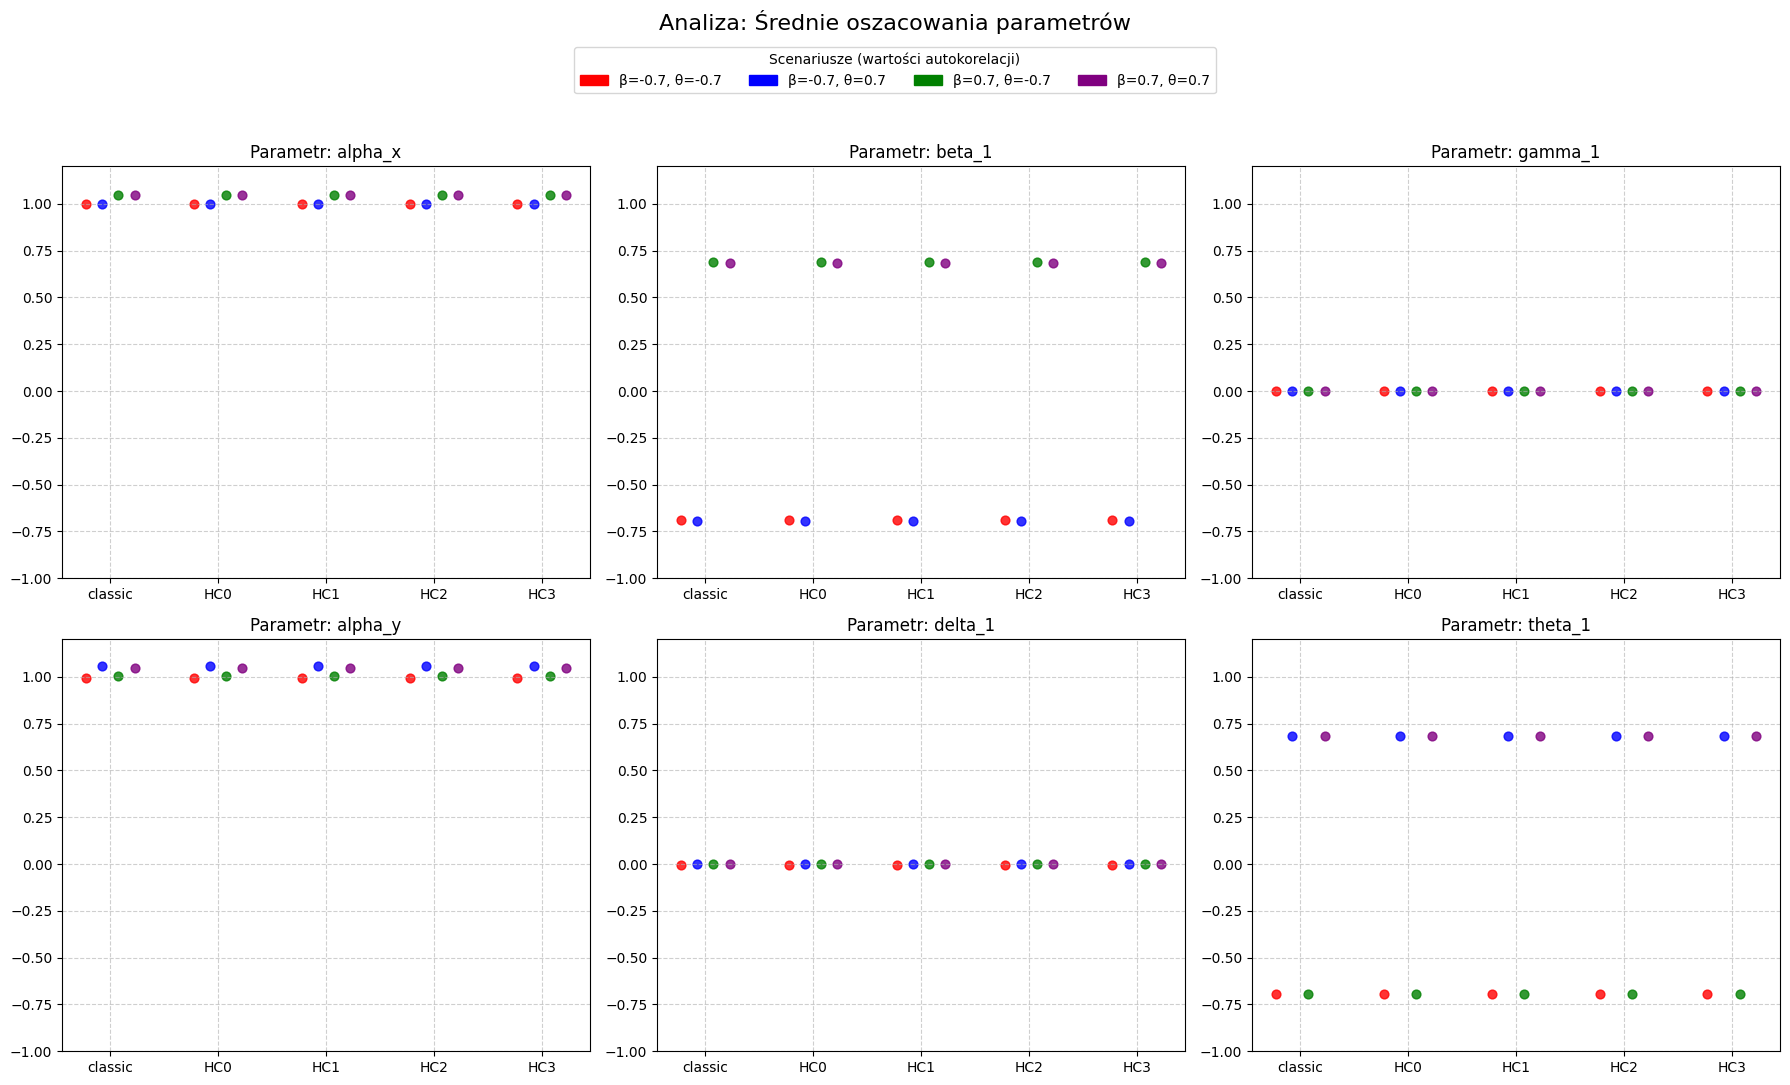

Generowanie wykresów obciążenia (bias)...


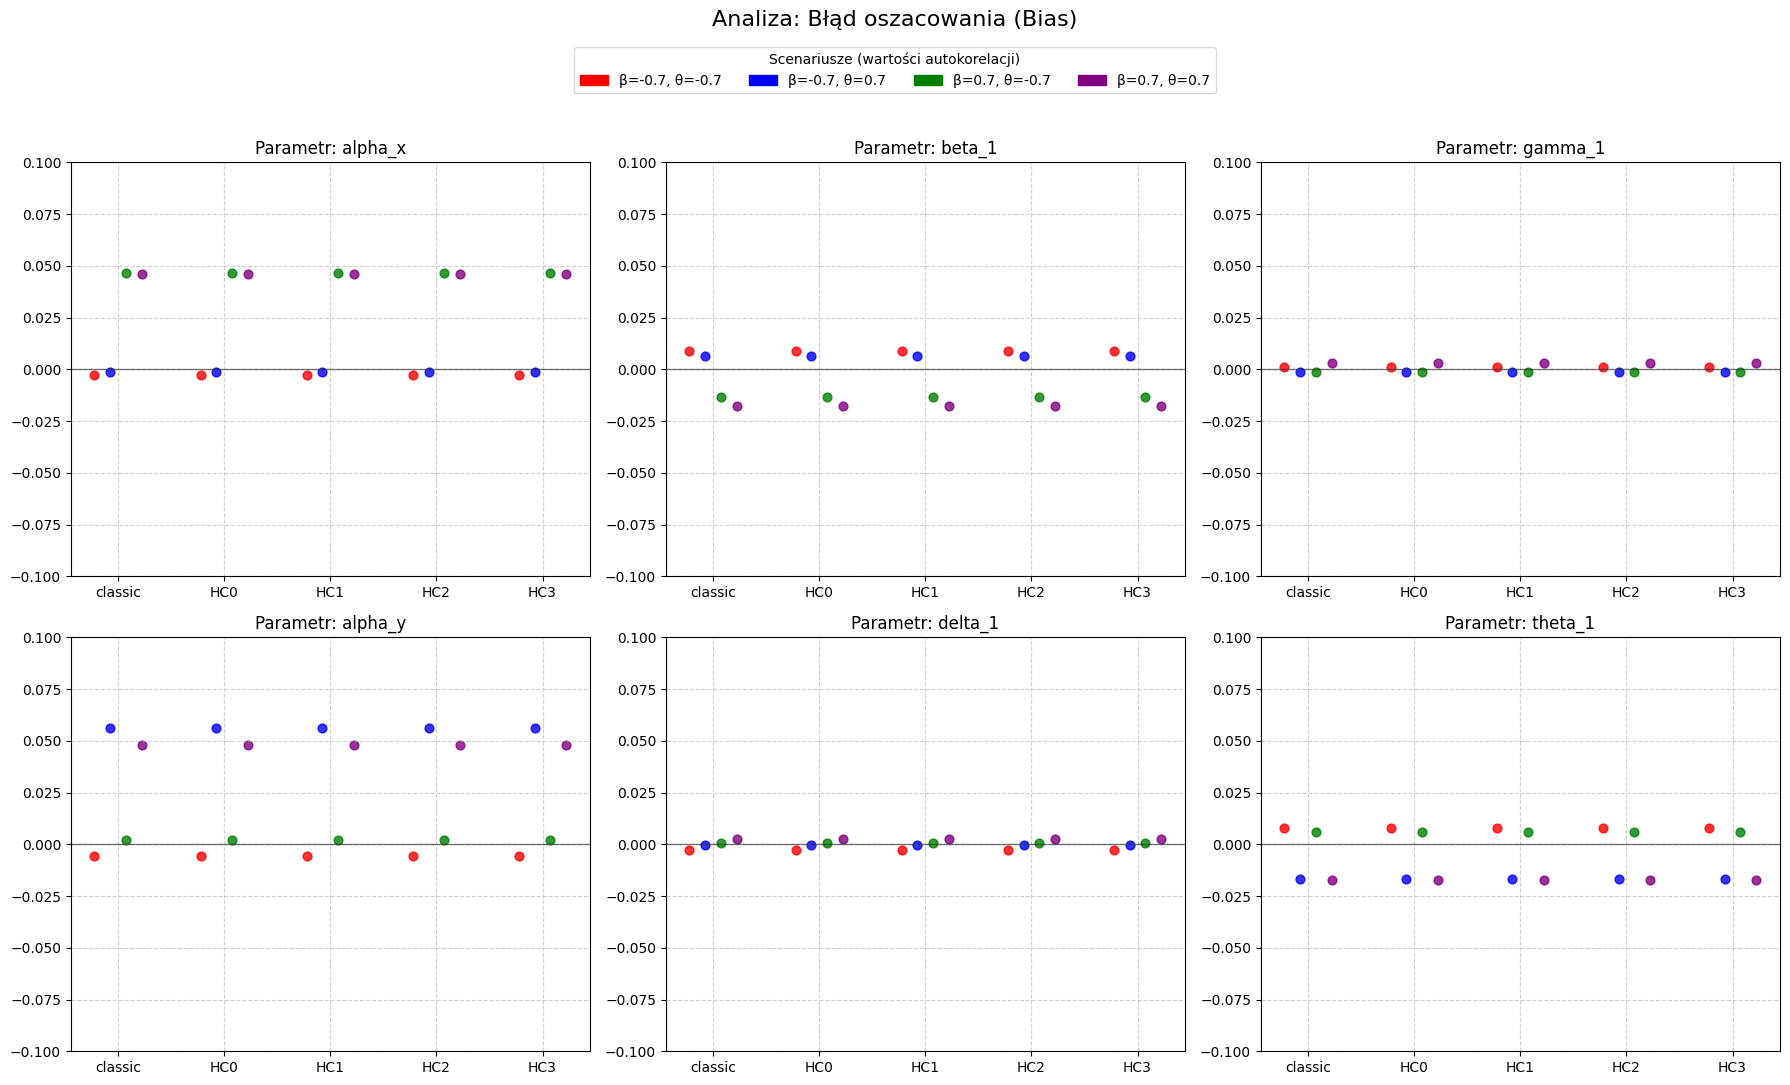

Generowanie wykresów rozmiaru testów...


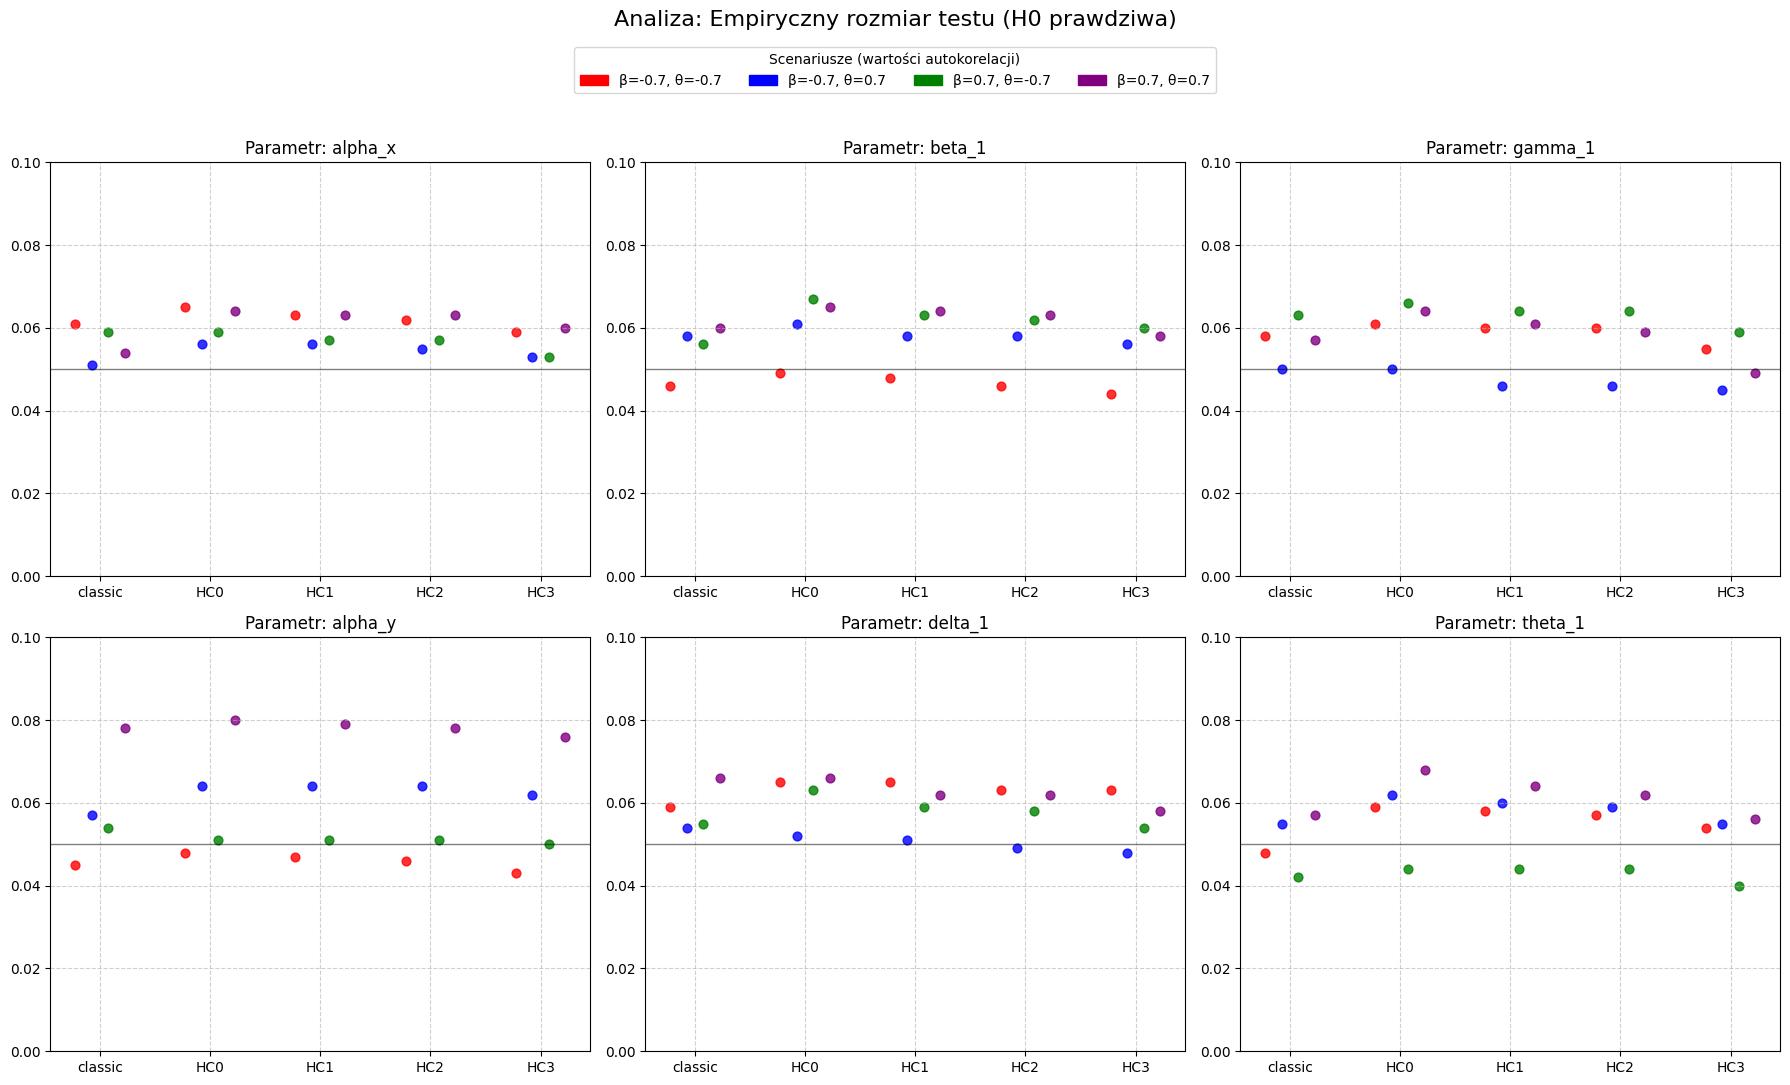

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Parametry do wykresów
PARAMS_TO_PLOT = ["alpha_x", "beta_1", "gamma_1", "alpha_y", "delta_1", "theta_1"]
SCENARIO_COLORS = {
    (-0.7, -0.7): "red",
    (-0.7, 0.7): "blue",
    (0.7, -0.7): "green",
    (0.7, 0.7): "purple"
}
X_TICKS = np.arange(len(HC_TYPES))
OFFSET_STEP = 0.15  # Przesunięcie dla "jittera"

def plot_simulation_metric(data_df, y_lim, title_metric, hline=None):
    """
    Ogólna funkcja rysująca siatkę 2x3 wykresów dla podanej metryki.
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    # Przygotowanie legendy (uchwyty dla kolorów)
    legend_patches = [
        mpatches.Patch(color=color, label=f"β={b}, θ={t}")
        for (b, t), color in SCENARIO_COLORS.items()
    ]

    for i, param_name in enumerate(PARAMS_TO_PLOT):
        ax = axes[i]
        
        # POPRAWKA: Używamy level=-1, aby mieć pewność, że wybieramy 
        # poziom z nazwami parametrów (alpha, beta...), niezależnie od 
        # tego jak Pandas nazwał pozostałe poziomy.
        try:
            subset = data_df.xs(param_name, level=-1)
        except KeyError:
            print(f"Nie znaleziono parametru {param_name} w indeksie.")
            continue
        
        # Iterujemy po scenariuszach. 
        # subset.iterrows() zwróci indeks (który jest krotką beta, theta) i wiersz danych.
        for j, (index_val, row) in enumerate(subset.iterrows()):
            # Obsługa przypadku, gdy indeks jest MultiIndexem lub krotką
            if isinstance(index_val, tuple) and len(index_val) >= 2:
                beta, theta = index_val[0], index_val[1]
            else:
                # Fallback, gdyby struktura była inna (np. pojedynczy indeks krotek)
                beta, theta = index_val
            
            # Pobieramy kolor
            # Używamy klucza (beta, theta), upewniając się że typy danych pasują
            color = SCENARIO_COLORS.get((float(beta), float(theta)), "black")
            
            # Obliczamy przesunięcie na osi X
            offset = (j - 1.5) * OFFSET_STEP
            x_positions = X_TICKS + offset
            
            # Rysujemy punkty
            ax.scatter(
                x_positions, 
                row[HC_TYPES], 
                color=color, 
                s=40, 
                alpha=0.8, 
                label=f"β={beta}, θ={theta}" if i == 0 else ""
            )

        # Ustawienia osi i wyglądu
        ax.set_title(f"Parametr: {param_name}")
        ax.set_xticks(X_TICKS)
        ax.set_xticklabels(HC_TYPES)
        ax.set_ylim(y_lim)
        ax.grid(True, linestyle='--', alpha=0.6)
        
        if hline is not None:
            ax.axhline(hline, color='black', linestyle='-', linewidth=1, alpha=0.5)

    # Legenda
    fig.legend(
        handles=legend_patches, 
        loc='upper center', 
        bbox_to_anchor=(0.5, 1.05), 
        ncol=4, 
        title="Scenariusze (wartości autokorelacji)"
    )
    
    plt.suptitle(f"Analiza: {title_metric}", y=1.08, fontsize=16)
    plt.tight_layout()
    plt.show()

# --- 1. Wykresy średnich estymatów parametrów ---
def plot_mean_estimates(mean_all):
    print("Generowanie wykresów średnich estymatów...")
    plot_simulation_metric(
        mean_all, 
        y_lim=(-1.0, 1.2), 
        title_metric="Średnie oszacowania parametrów"
    )

# --- 2. Wykresy błędów (Bias) ---
def plot_bias_estimates(bias_all):
    print("Generowanie wykresów obciążenia (bias)...")
    plot_simulation_metric(
        bias_all, 
        y_lim=(-0.1, 0.1), 
        title_metric="Błąd oszacowania (Bias)",
        hline=0.0
    )

# --- 3. Wykresy rozmiarów testów (Empirical Size) ---
def plot_test_sizes(reject_all):
    print("Generowanie wykresów rozmiaru testów...")
    plot_simulation_metric(
        reject_all, 
        y_lim=(0.0, 0.1), 
        title_metric="Empiryczny rozmiar testu (H0 prawdziwa)",
        hline=ALPHA
    )

# --- Uruchomienie funkcji rysujących ---
# Upewnij się, że ramki danych (mean_all, bias_all, reject_all) istnieją w pamięci
plot_mean_estimates(mean_all)
plot_bias_estimates(bias_all)
plot_test_sizes(reject_all)

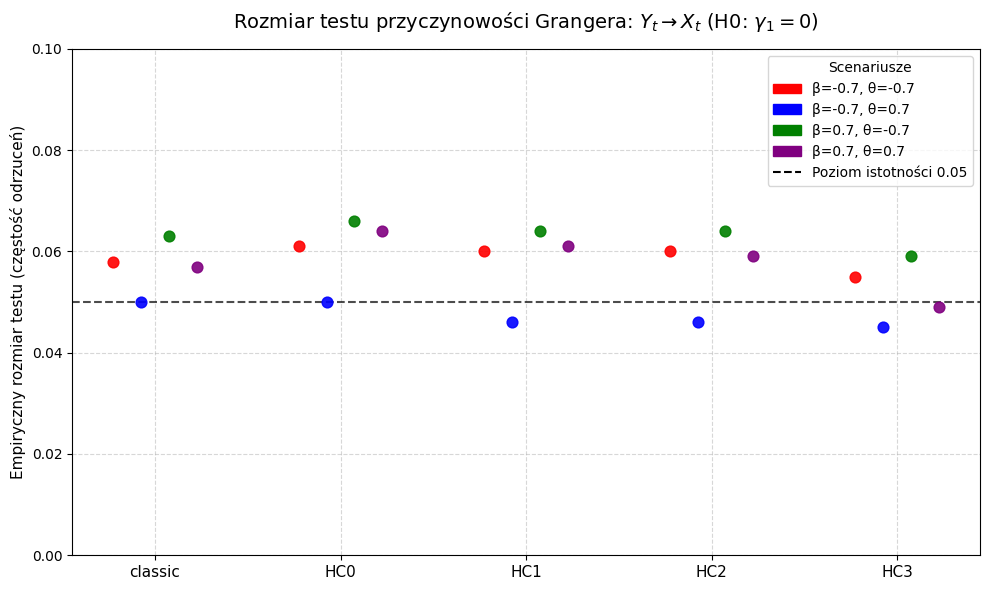

In [12]:
def plot_causality_size(causality_df):
    """
    Rysuje pojedynczy wykres empirycznego rozmiaru testu przyczynowości Y -> X.
    Oś Y: 0 do 0.1.
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Parametry pomocnicze
    x_base = np.arange(len(HC_TYPES))
    
    # Tworzenie legendy (uchwyty kolorów) - spójne z poprzednimi wykresami
    legend_patches = [
        mpatches.Patch(color=color, label=f"β={b}, θ={t}")
        for (b, t), color in SCENARIO_COLORS.items()
    ]

    # Iterujemy po wierszach ramki causality_all
    # Zakładamy, że kolejność wierszy odpowiada kolejności w PARAM_GRID,
    # co wynika z konstrukcji pętli (concat z ignore_index=True).
    for i, row in causality_df.iterrows():
        beta = row["beta_1_true"]
        theta = row["theta_1_true"]
        
        # Pobieramy kolor dla danej pary parametrów
        color = SCENARIO_COLORS.get((float(beta), float(theta)), "black")
        
        # Obliczamy przesunięcie (jitter)
        # i przyjmuje wartości 0, 1, 2, 3 -> przesuwamy wokół środka
        offset = (i - 1.5) * OFFSET_STEP
        x_positions = x_base + offset
        
        # Wybieramy tylko kolumny z wynikami estymatorów
        y_values = row[HC_TYPES]
        
        # Rysujemy punkty
        ax.scatter(
            x_positions, 
            y_values, 
            color=color, 
            s=60,       # Nieco większe punkty niż na siatce 2x3
            alpha=0.9, 
            zorder=3    # Punkty na wierzchu siatki
        )

    # Linia pozioma oznaczająca poziom istotności alpha = 0.05
    ax.axhline(ALPHA, color='black', linestyle='--', linewidth=1.5, alpha=0.7, label=f"α = {ALPHA}")

    # Ustawienia osi i wyglądu
    ax.set_xticks(x_base)
    ax.set_xticklabels(HC_TYPES, fontsize=11)
    ax.set_ylim(0, 0.1)
    ax.set_ylabel("Empiryczny rozmiar testu (częstość odrzuceń)", fontsize=11)
    ax.set_title("Rozmiar testu przyczynowości Grangera: $Y_t \\to X_t$ (H0: $\\gamma_1 = 0$)", fontsize=14, pad=15)
    ax.grid(True, linestyle='--', alpha=0.5, zorder=0)

    # Dodanie legendy (kolory scenariuszy + linia alpha)
    # Dodajemy linię alpha do legendy ręcznie
    from matplotlib.lines import Line2D
    line_patch = Line2D([0], [0], color='black', linestyle='--', label=f'Poziom istotności {ALPHA}')
    
    ax.legend(
        handles=legend_patches + [line_patch],
        loc='upper right',
        title="Scenariusze"
    )

    plt.tight_layout()
    plt.show()

# --- Uruchomienie funkcji ---
plot_causality_size(causality_all)

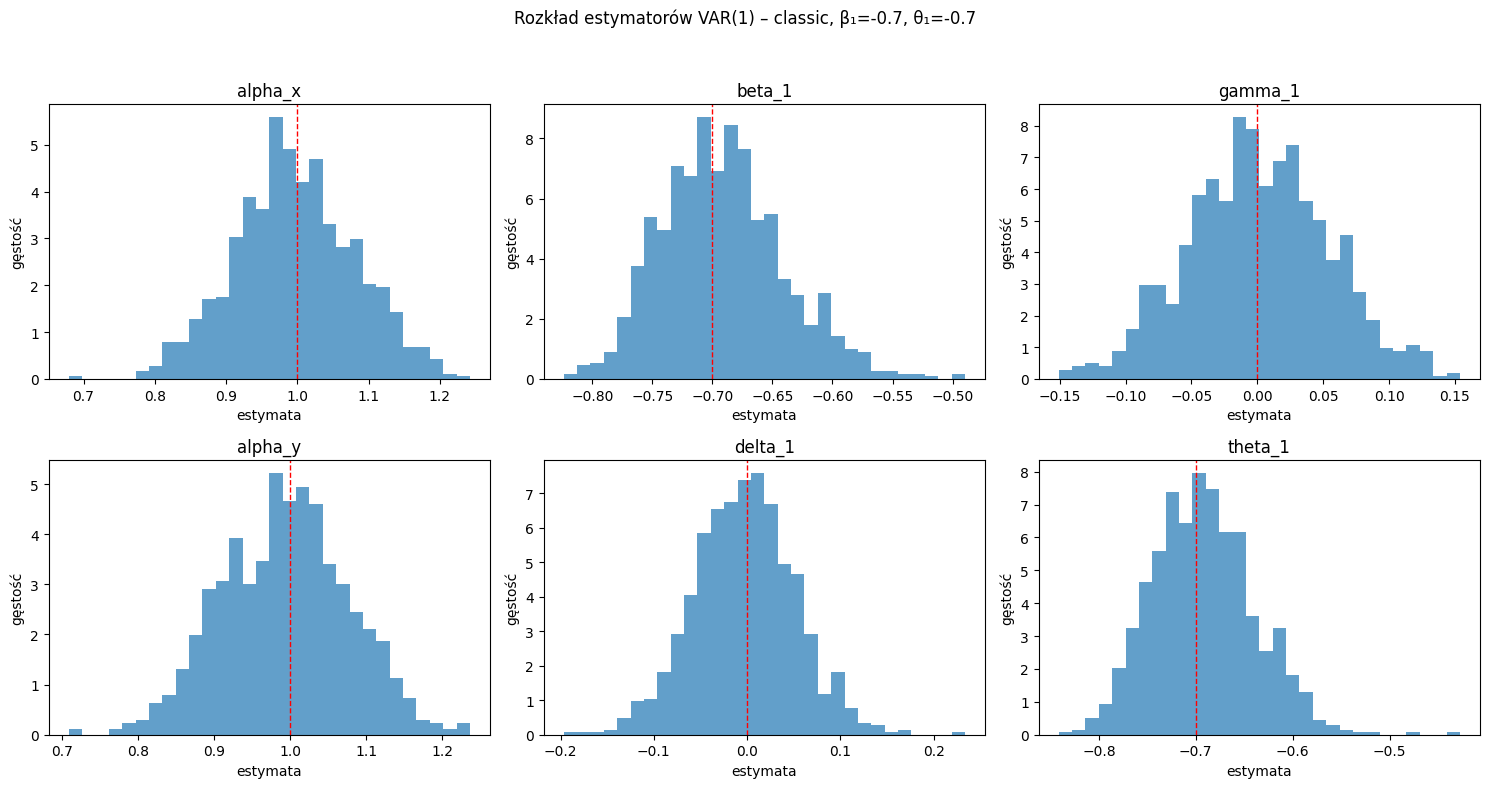

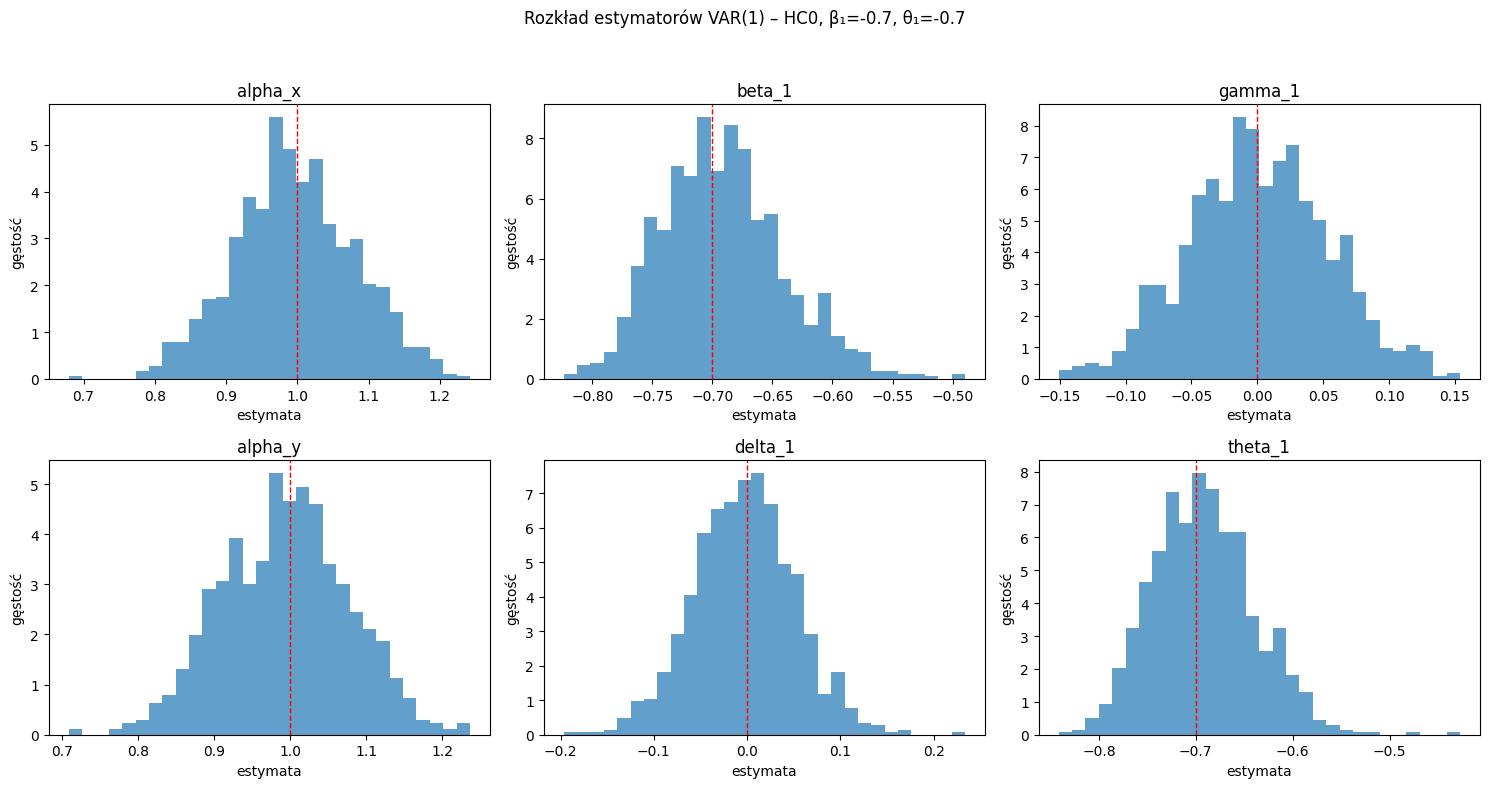

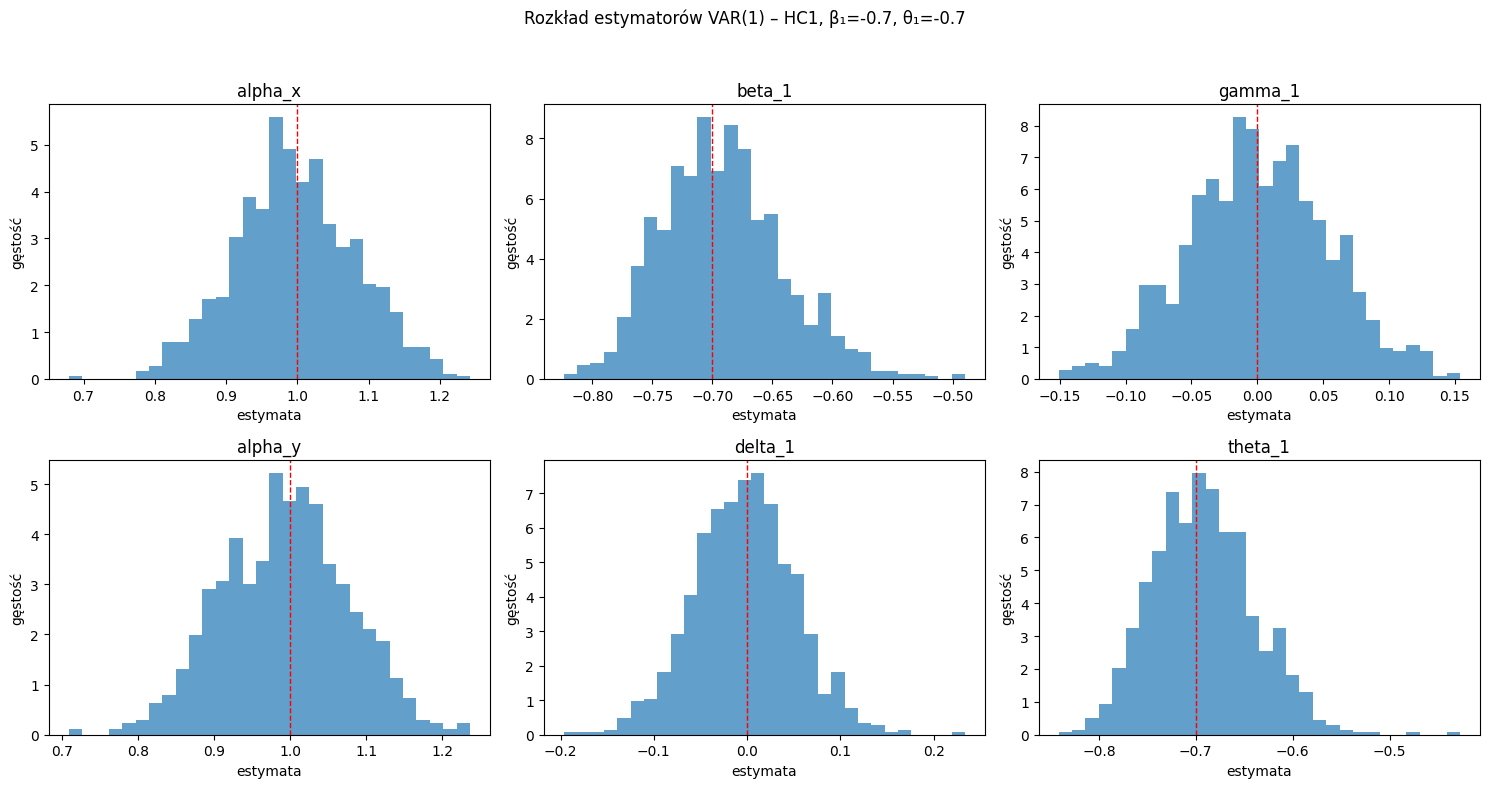

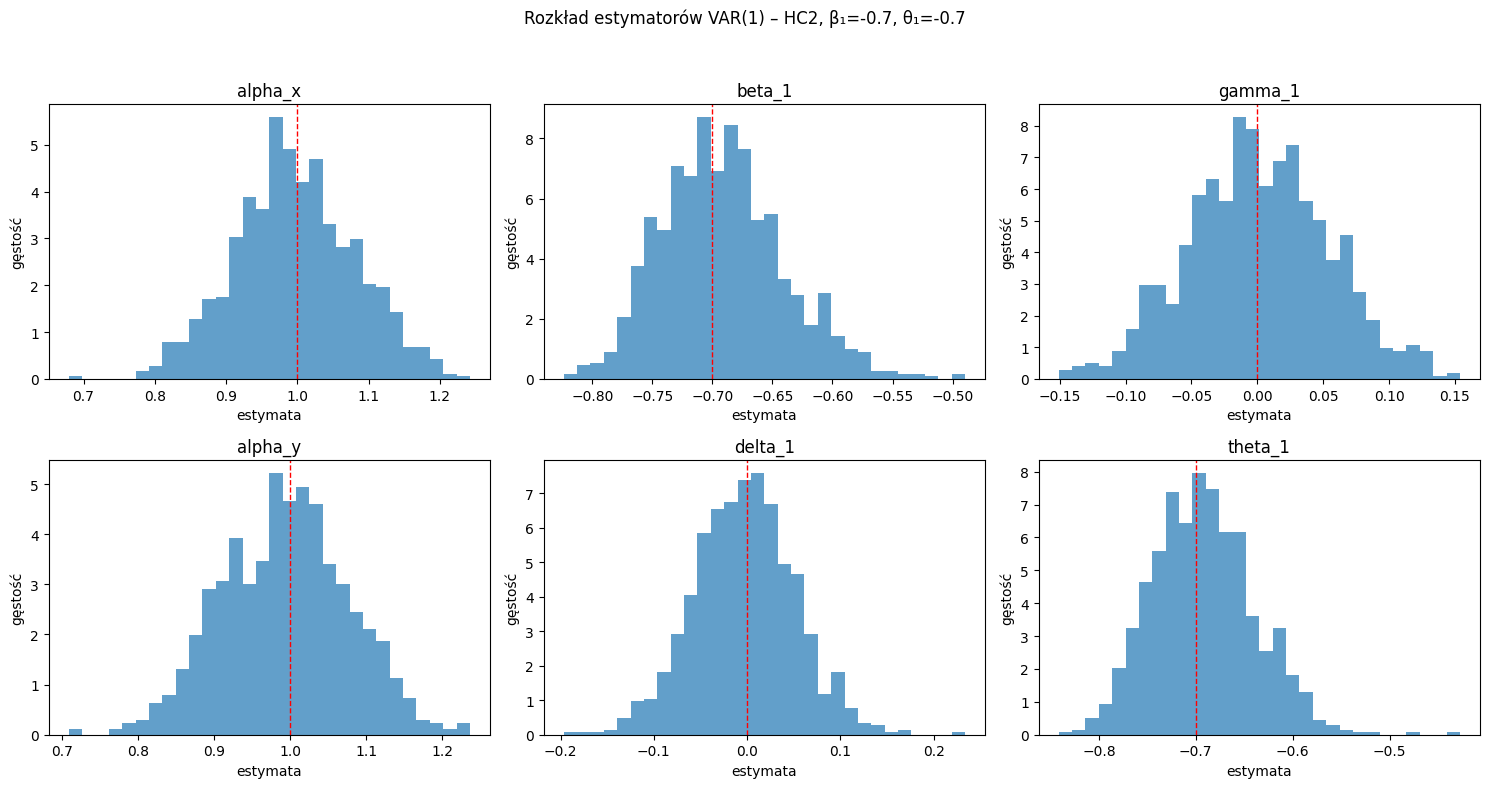

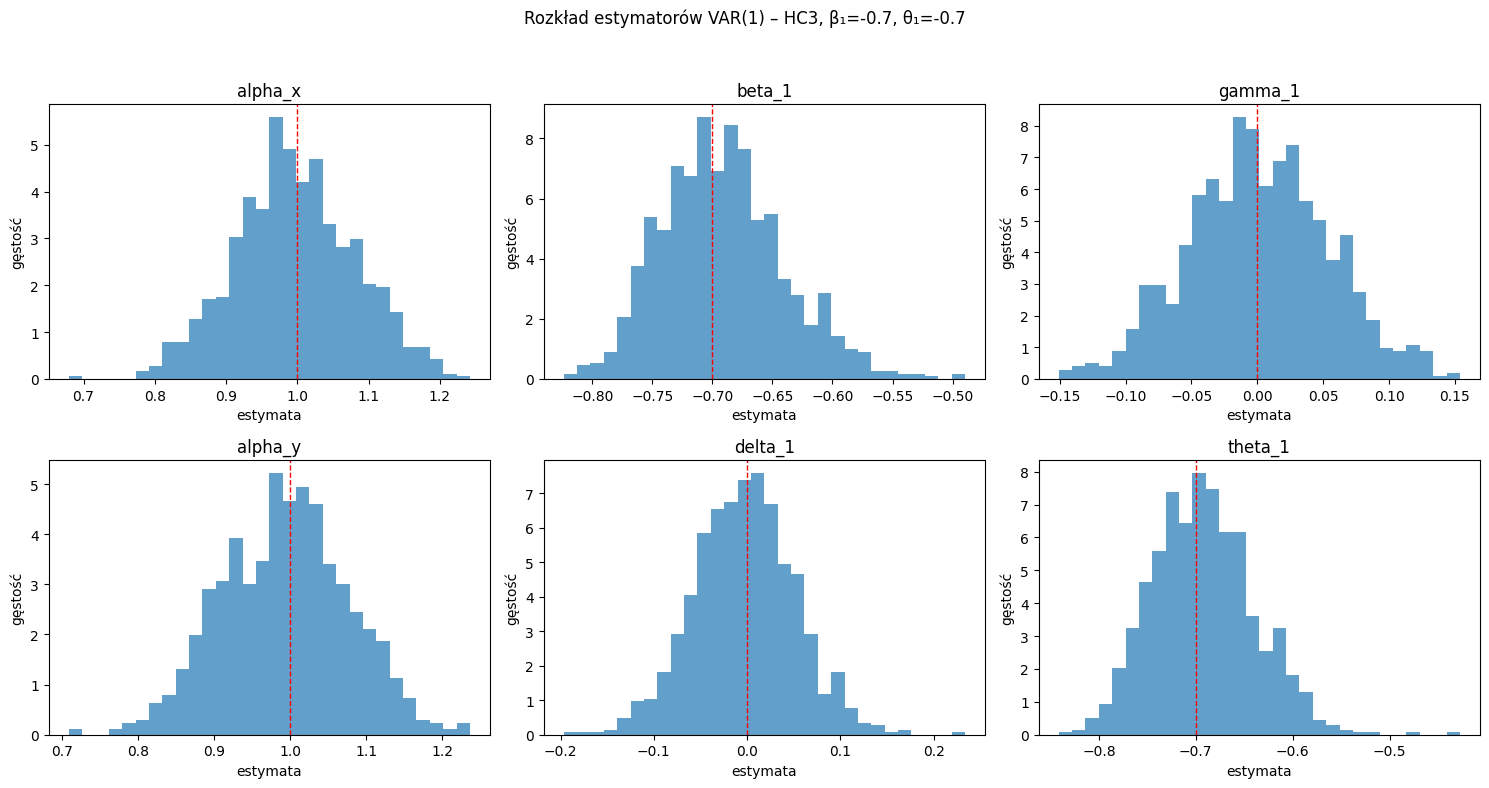

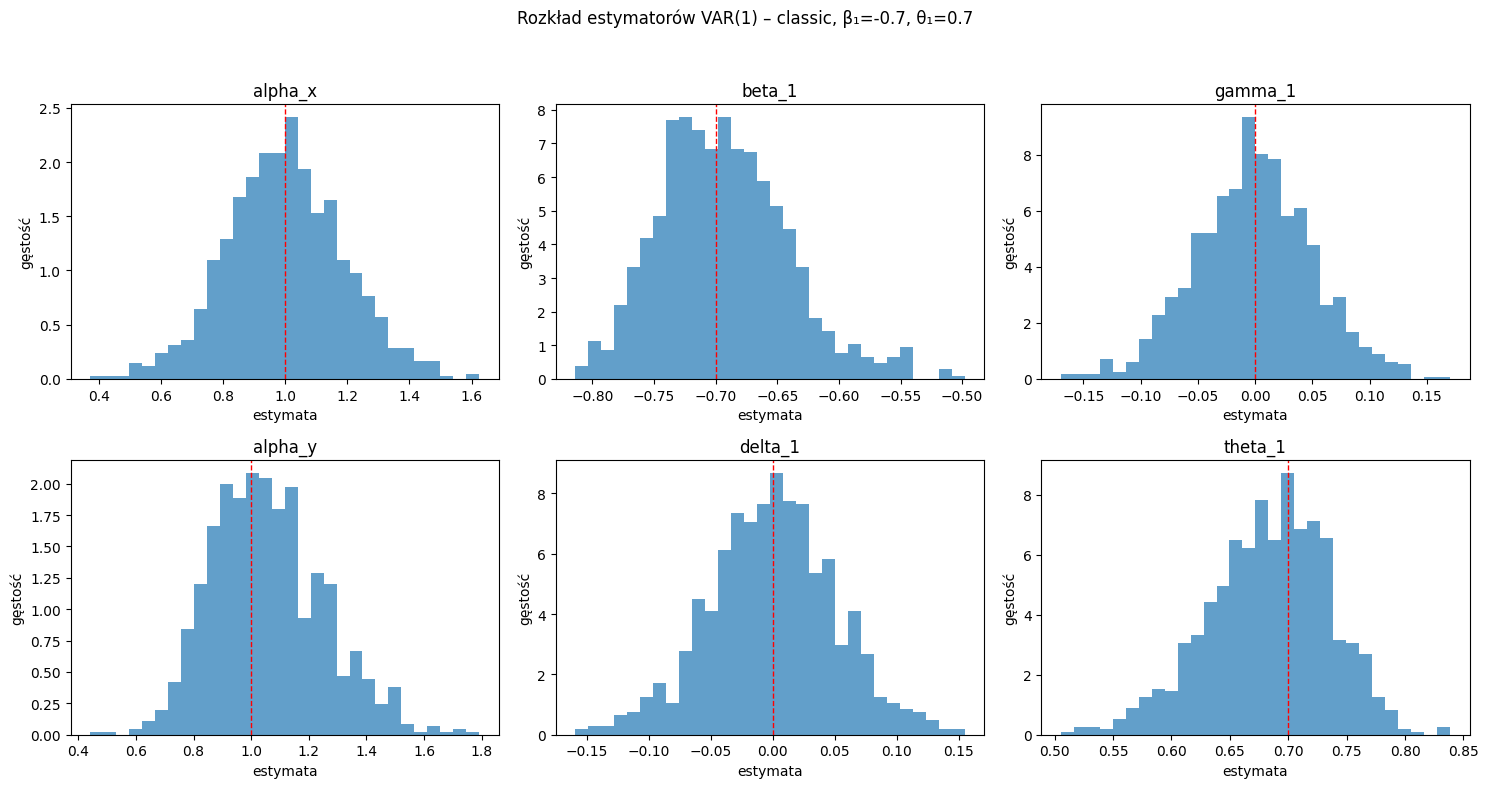

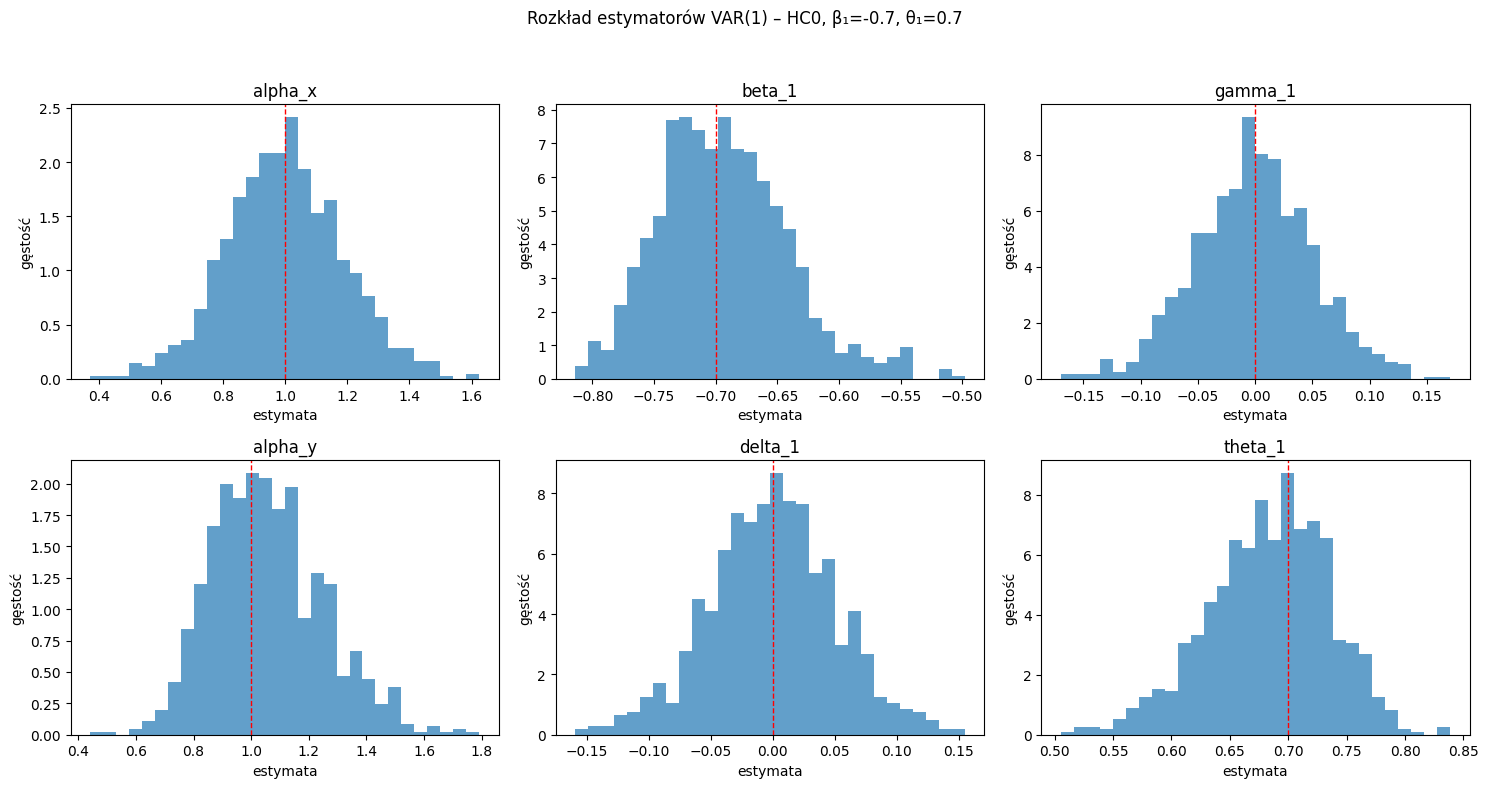

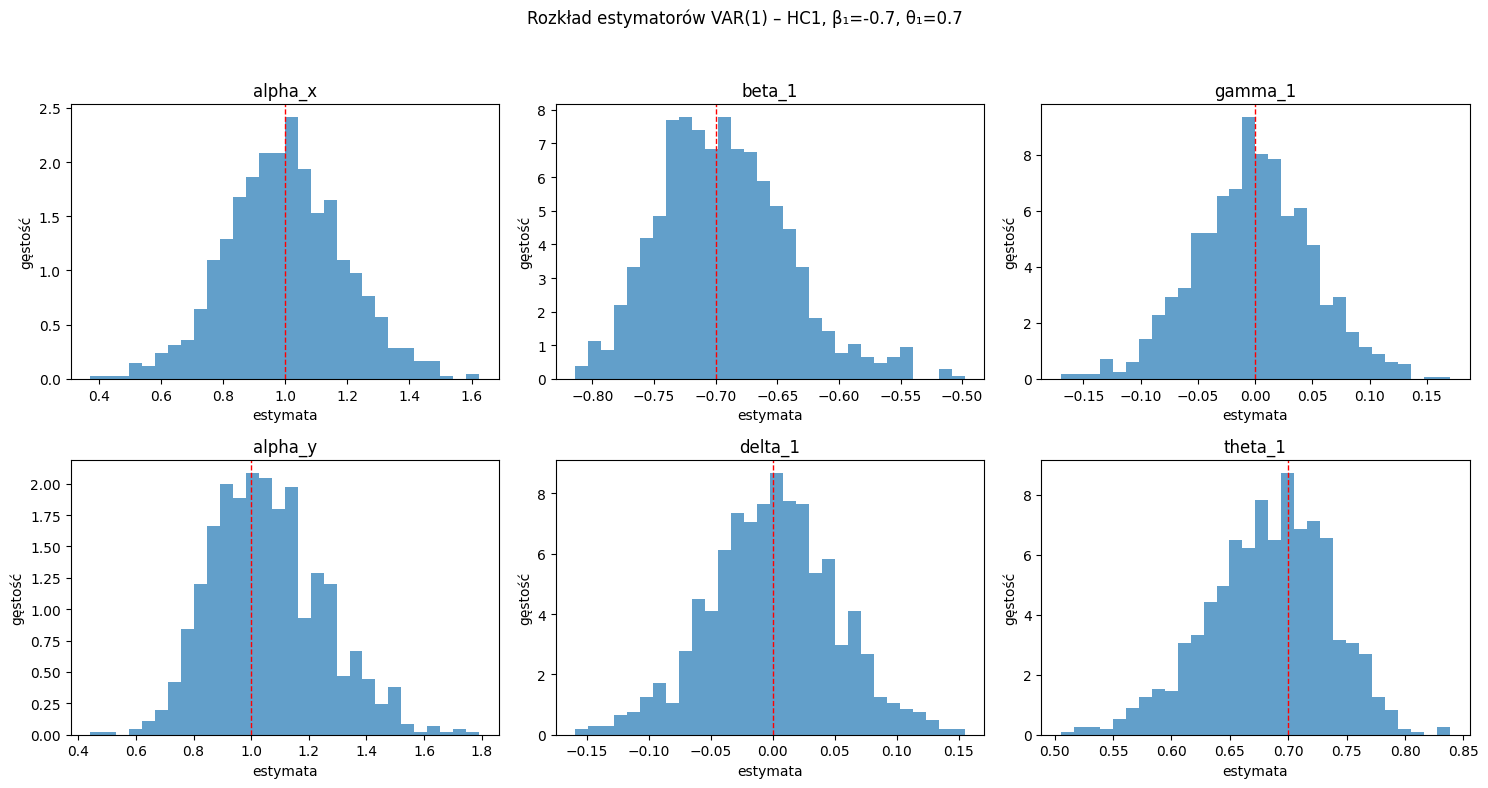

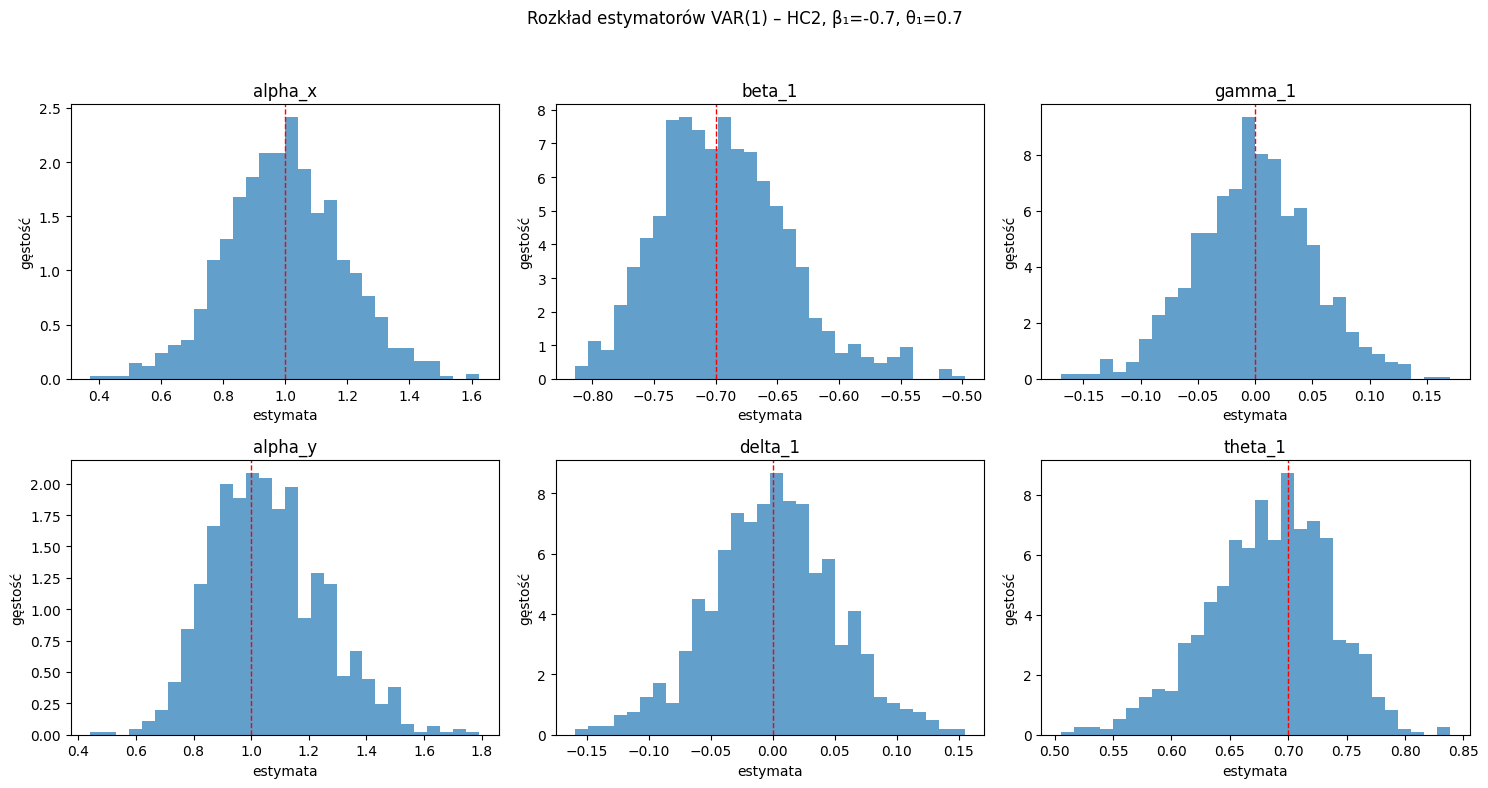

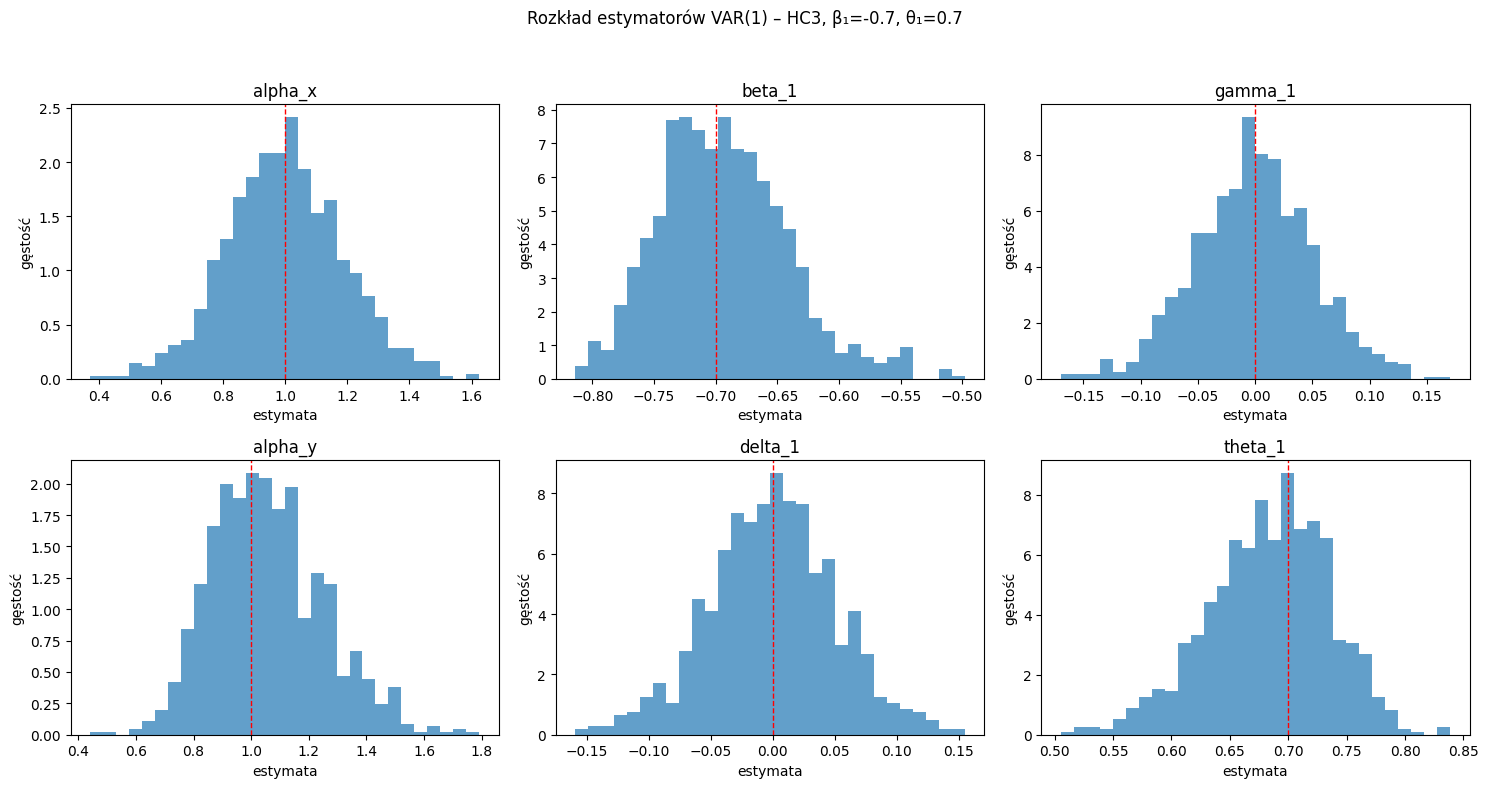

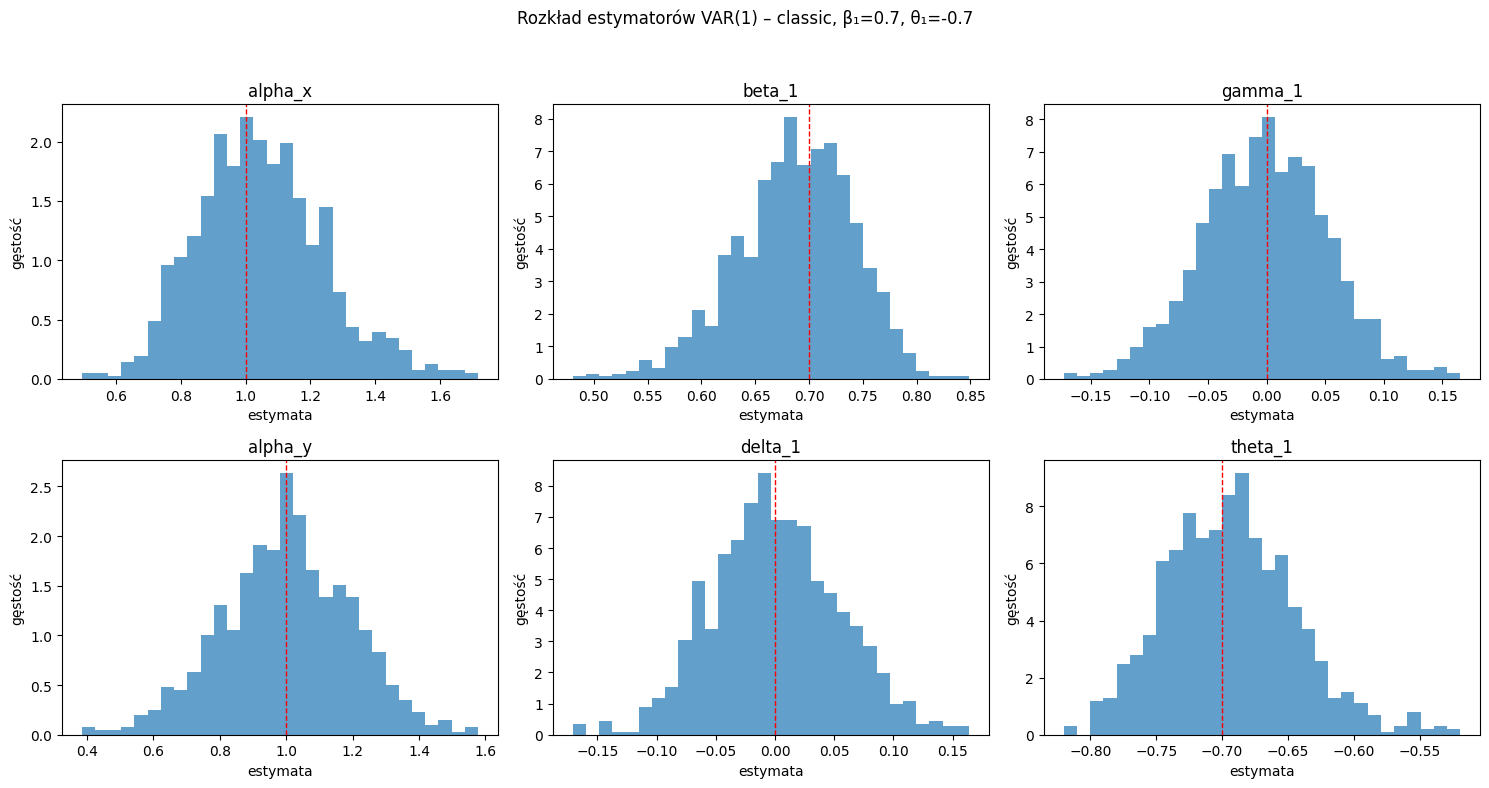

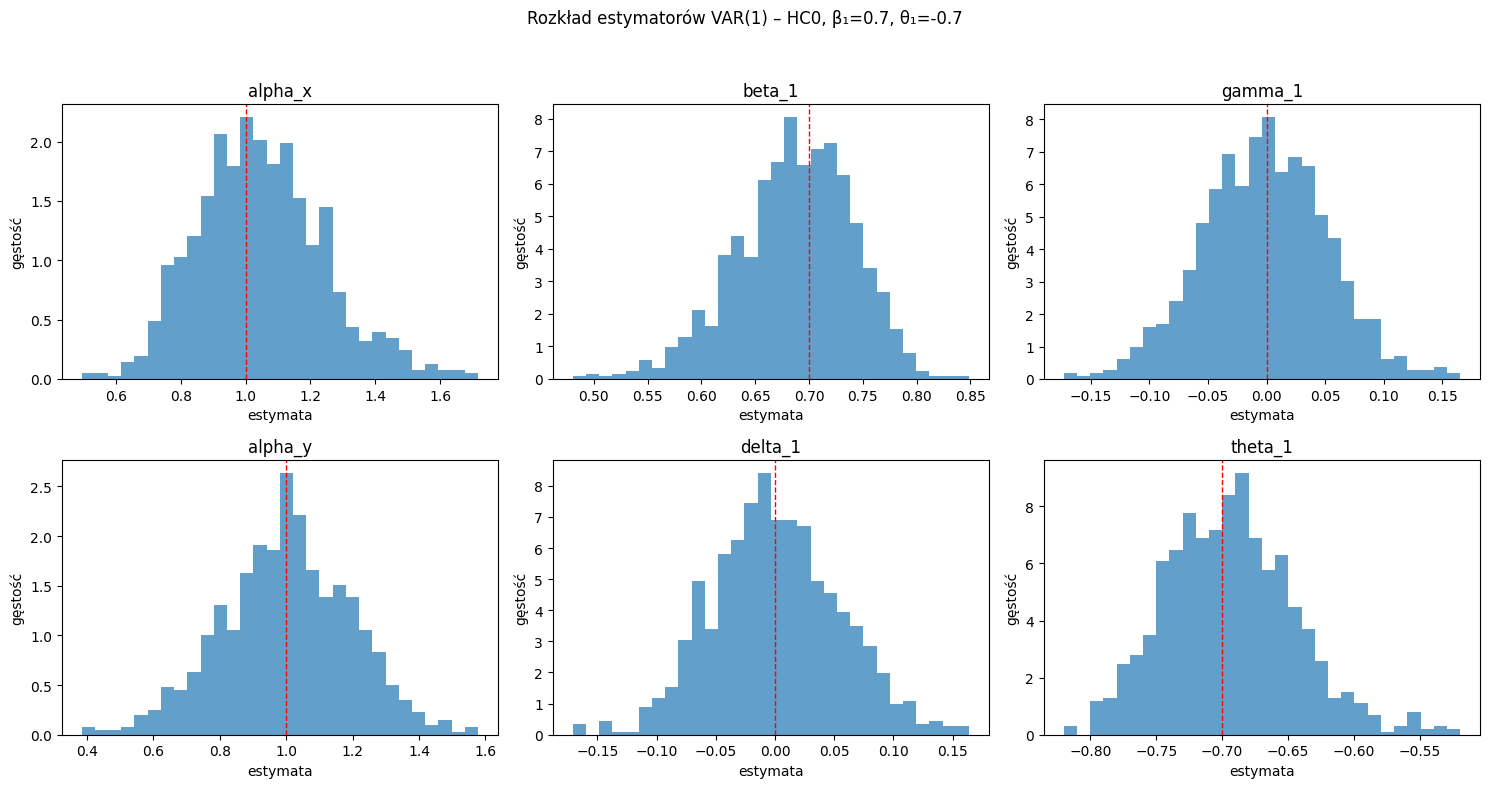

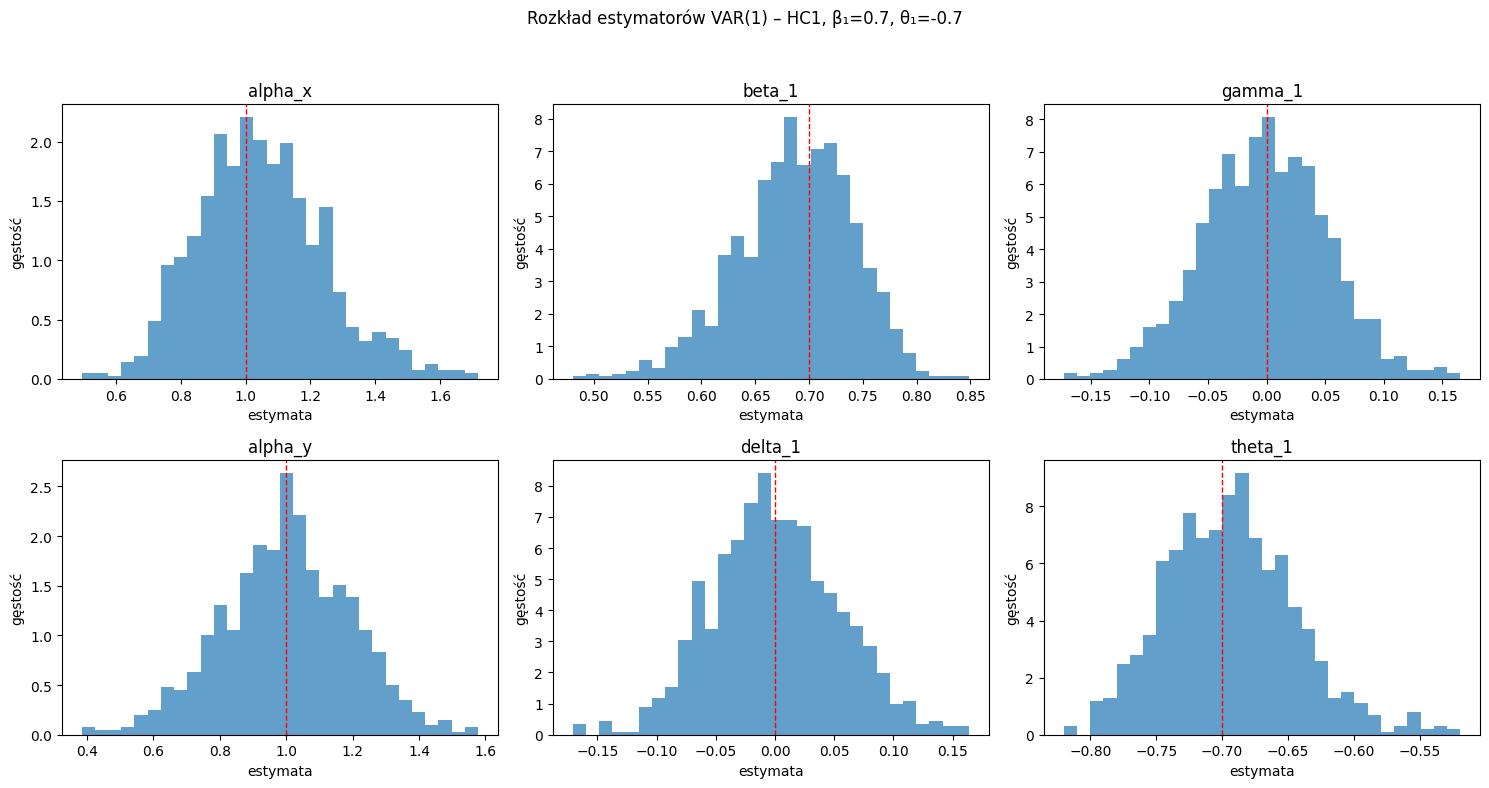

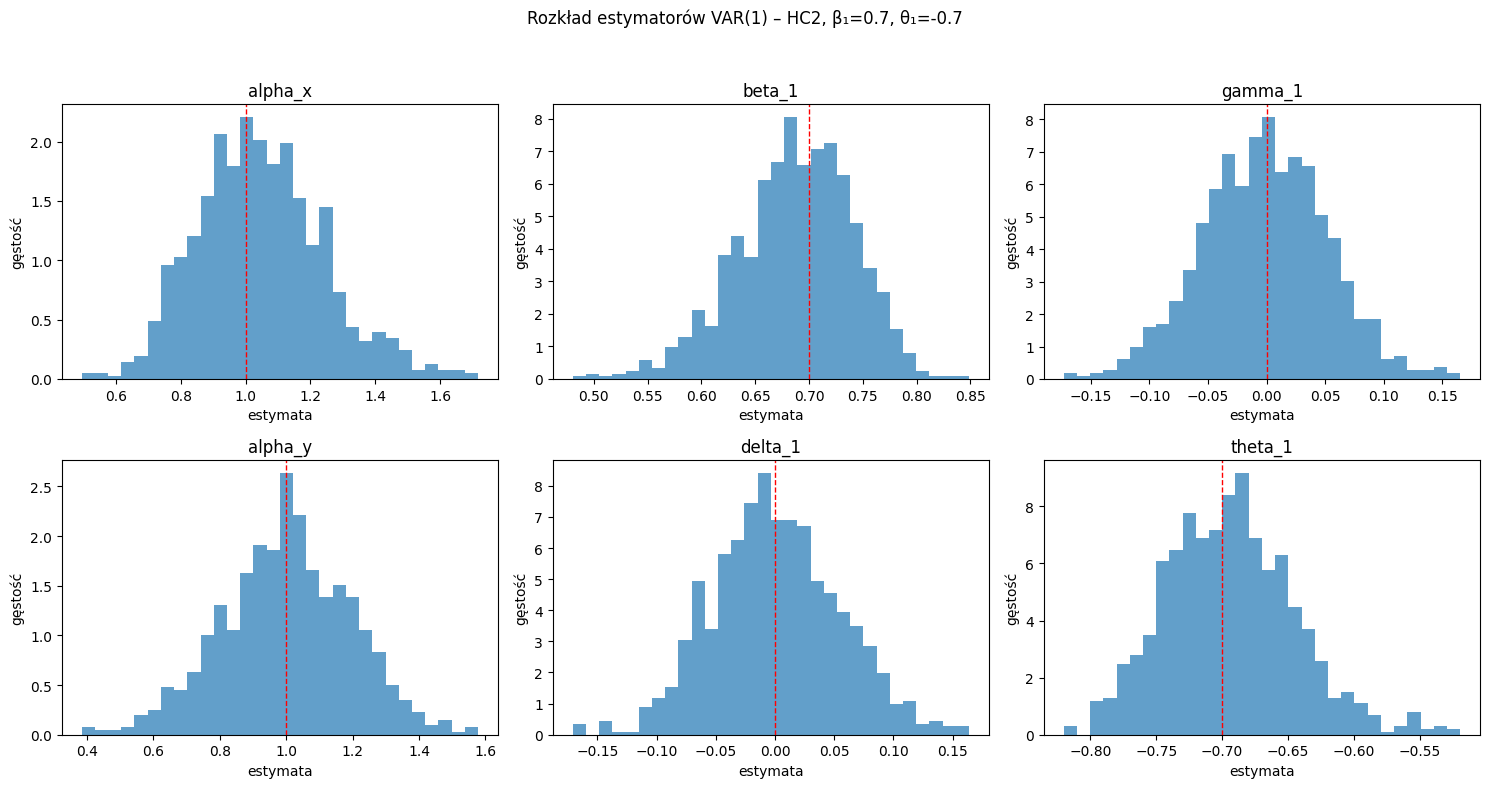

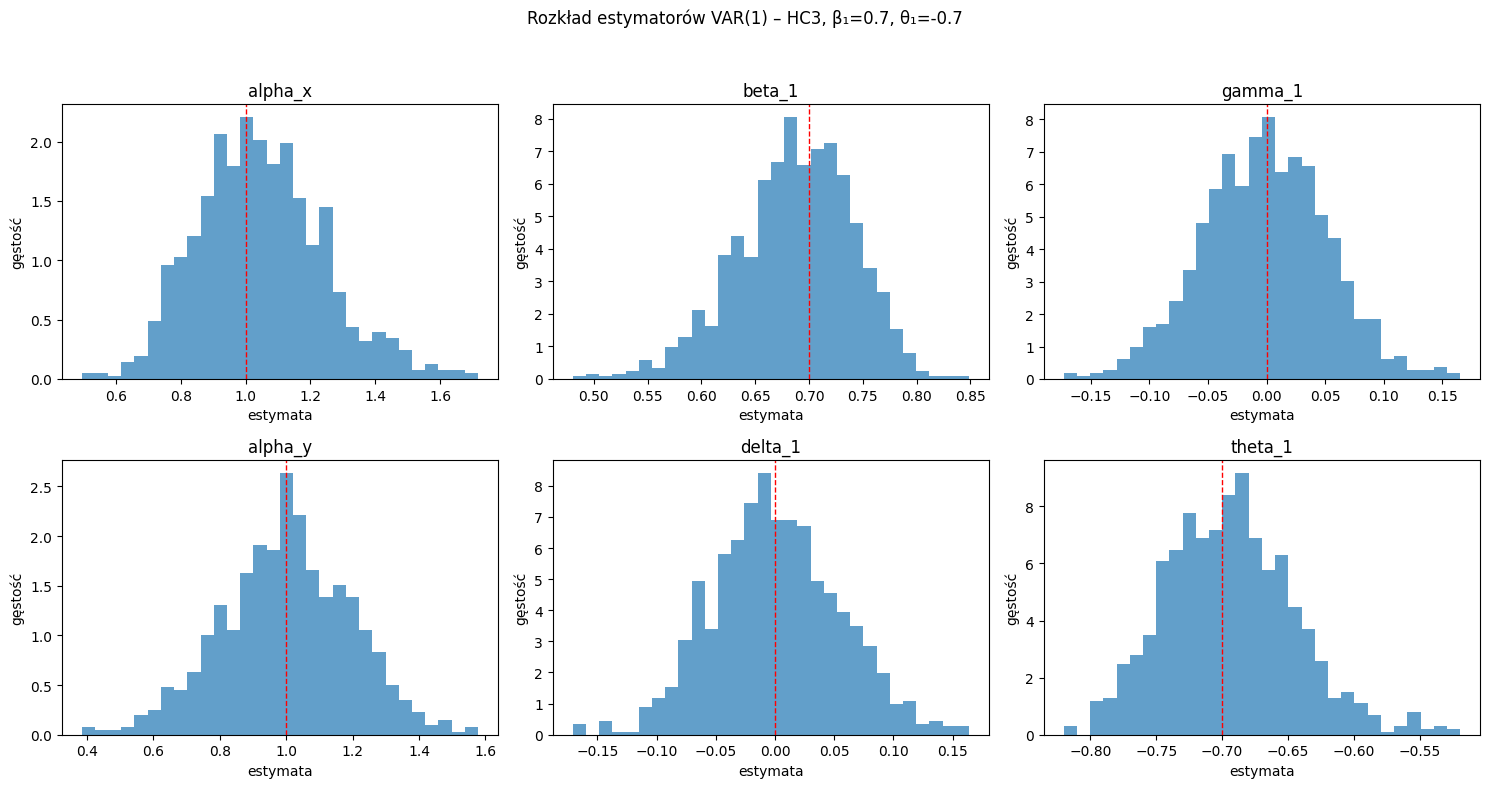

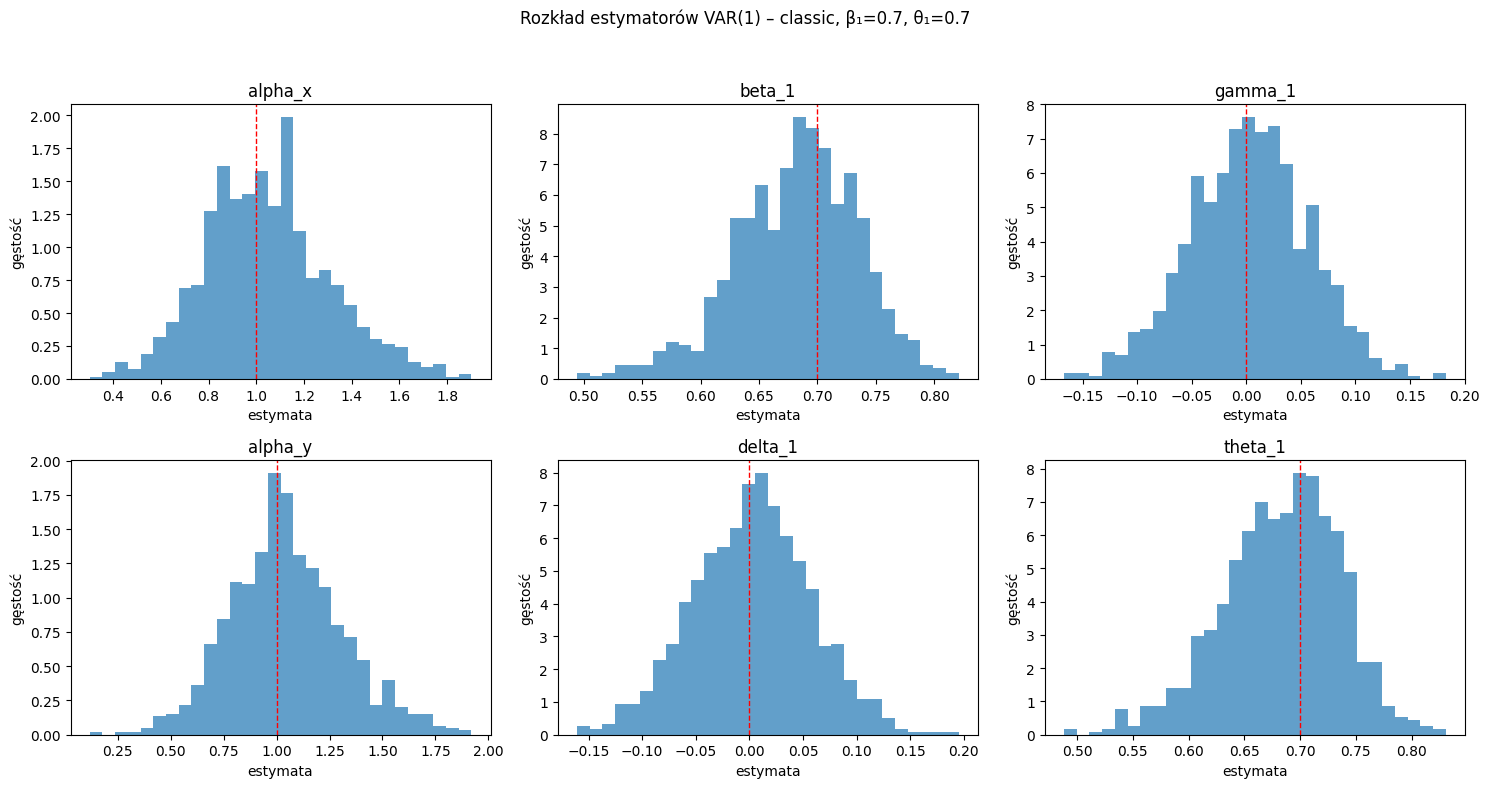

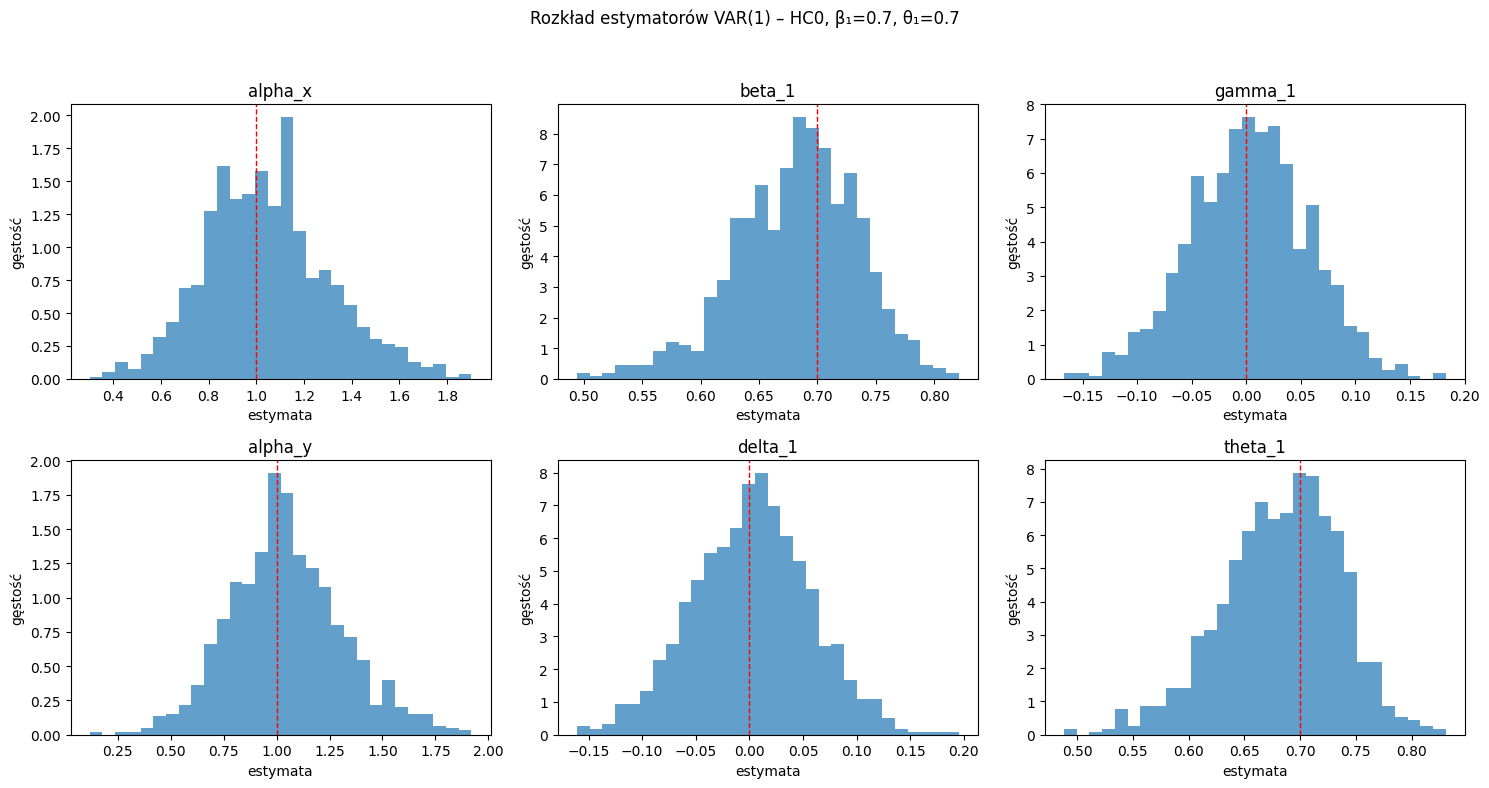

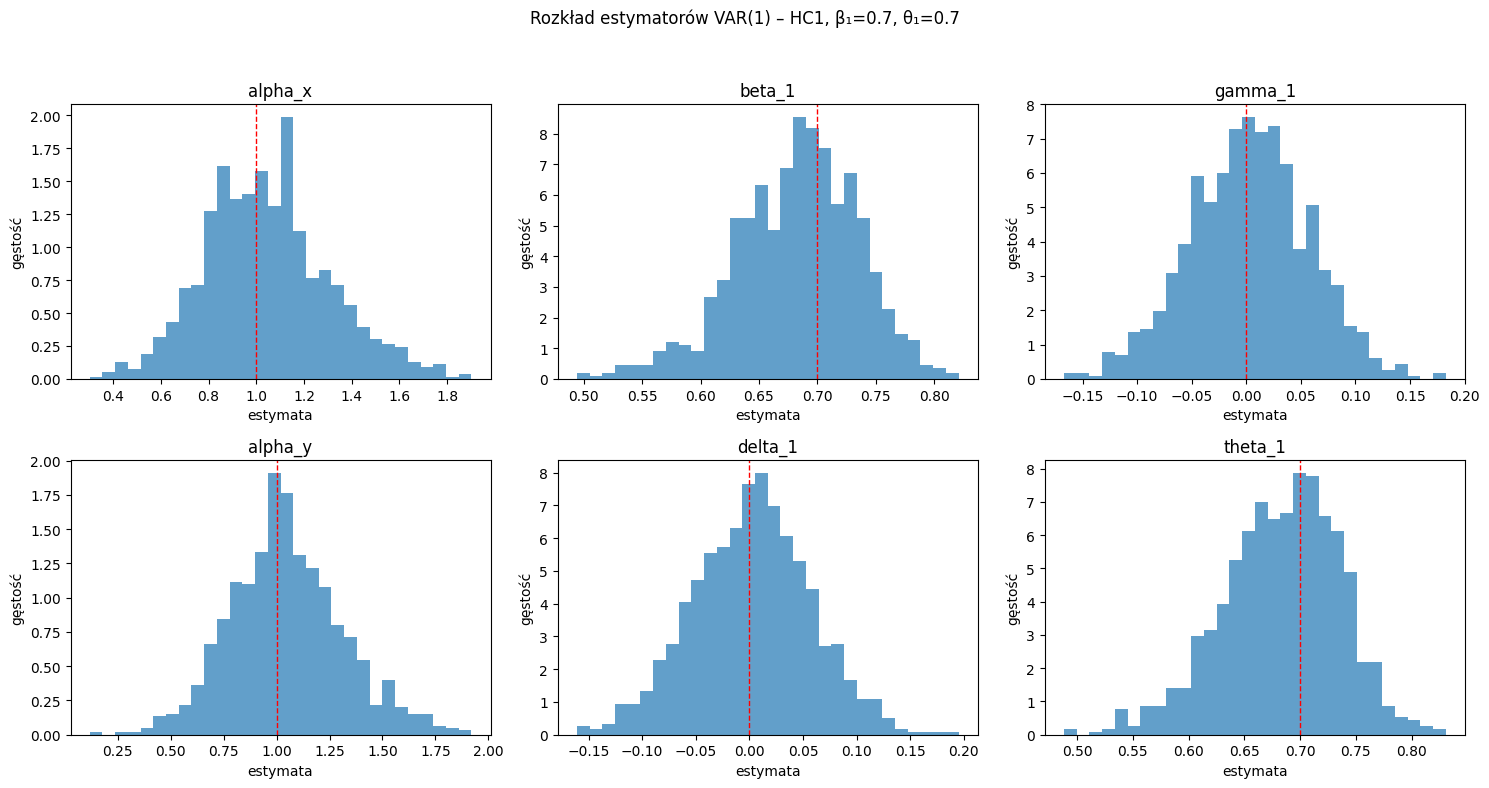

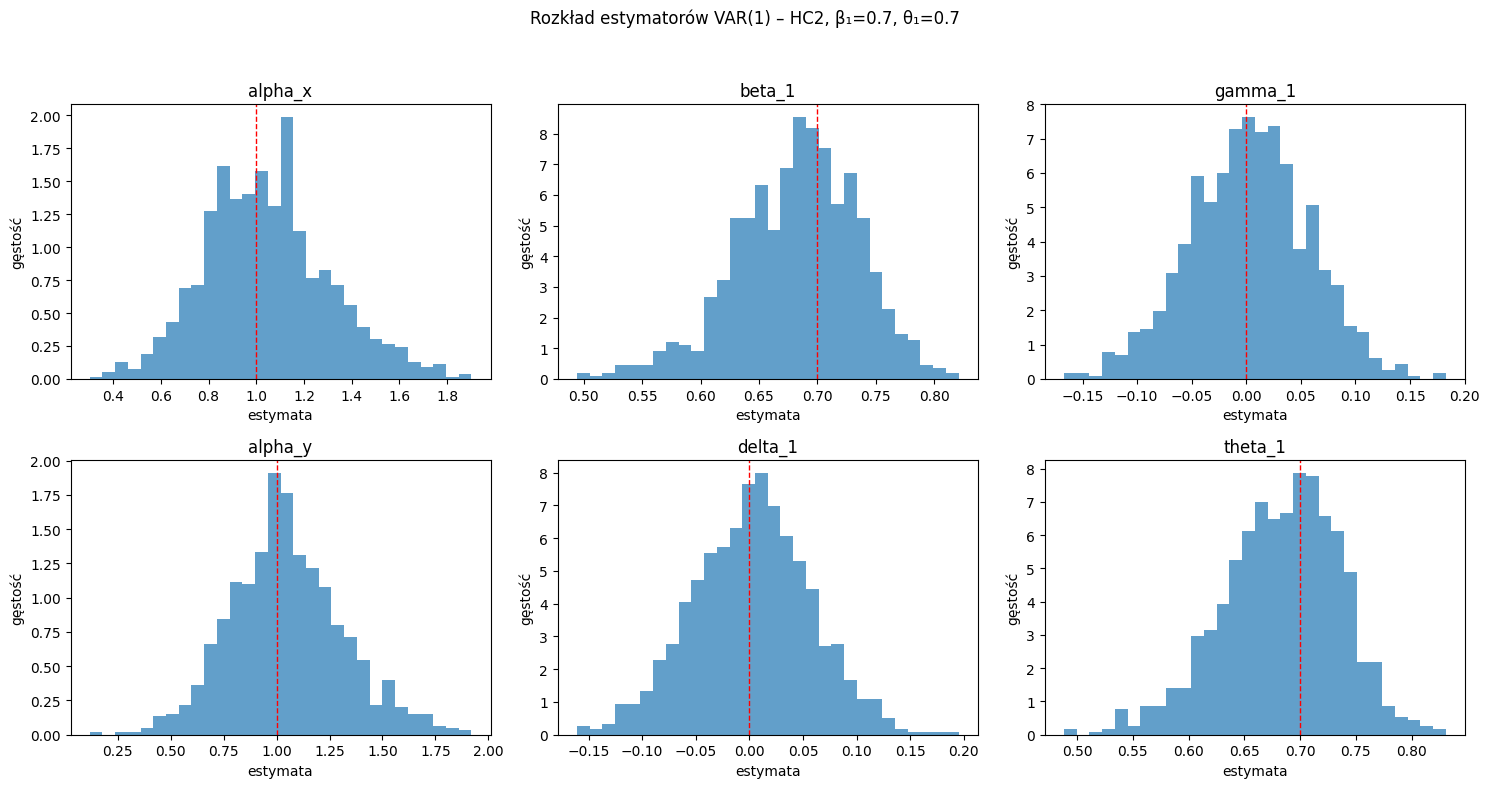

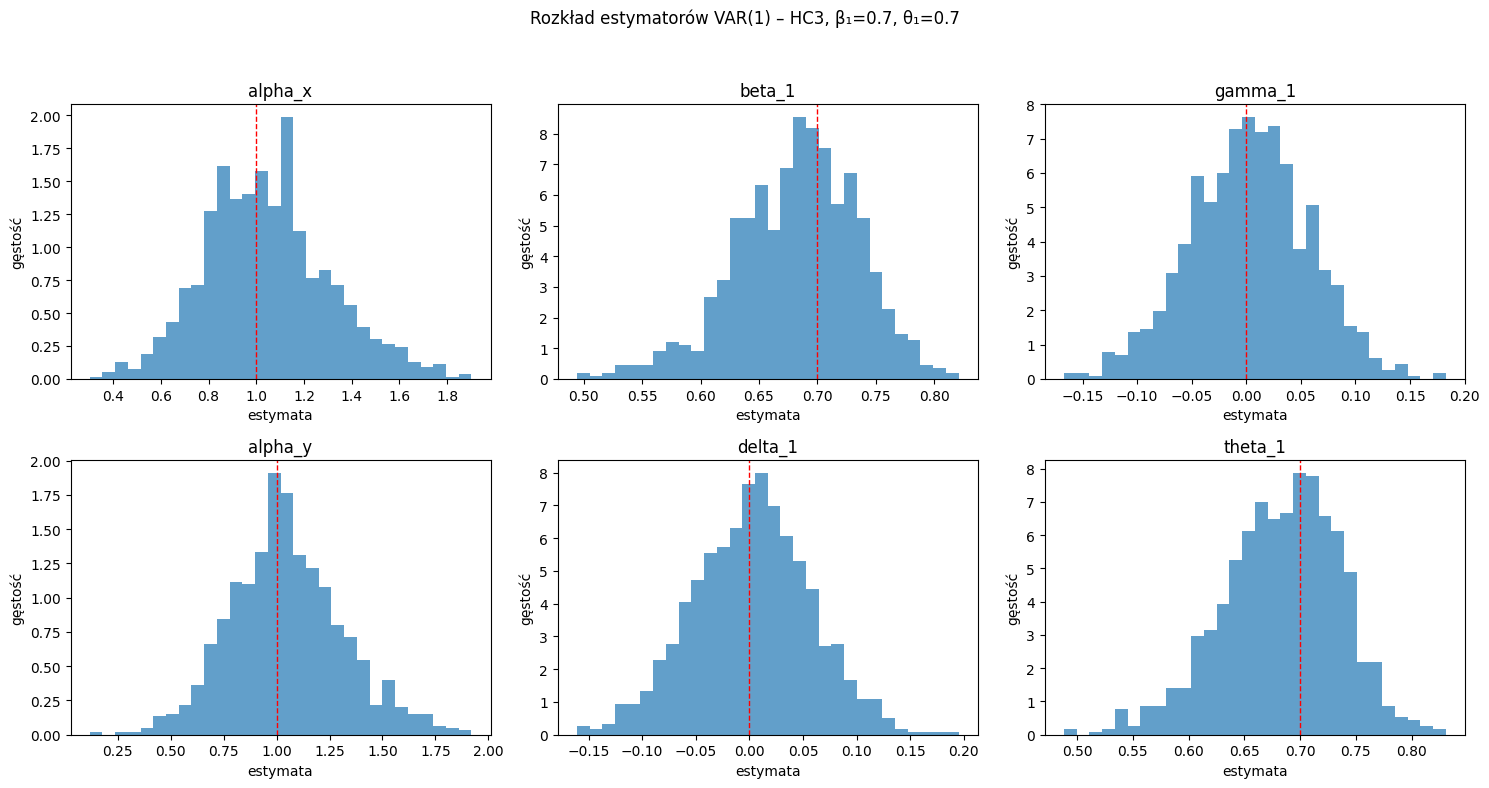

In [55]:
# Wykres 1: rozkład estymatorów parametrów w poszczególnych scenariuszach i dla różnych estymatorów HC
params = ["alpha_x", "beta_1", "gamma_1", "alpha_y", "delta_1", "theta_1"]

for beta_1, theta_1 in PARAM_GRID:
    true_values = {
        "alpha_x": ALPHA_X,
        "beta_1": beta_1,
        "gamma_1": GAMMA_1,
        "alpha_y": ALPHA_Y,
        "delta_1": DELTA_1,
        "theta_1": theta_1,
    }
    estimates = all_estimates[(beta_1, theta_1)]
    estimates_df = {hc: pd.DataFrame(records) for hc, records in estimates.items()}

    for hc in HC_TYPES:
        fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=False, sharey=False)
        axes = axes.ravel()
        for ax, param in zip(axes, params):
            series = estimates_df[hc][param]
            ax.hist(
                series,
                bins=30,
                density=True,
                alpha=0.7,
                color="tab:blue",
            )
            ax.axvline(
                true_values[param],
                color="red",
                linestyle="--",
                linewidth=1,
            )
            ax.set_title(param)
            ax.set_xlabel("estymata")
            ax.set_ylabel("gęstość")
        fig.suptitle(
            f"Rozkład estymatorów VAR(1) – {hc}, β₁={beta_1}, θ₁={theta_1}"
        )
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()


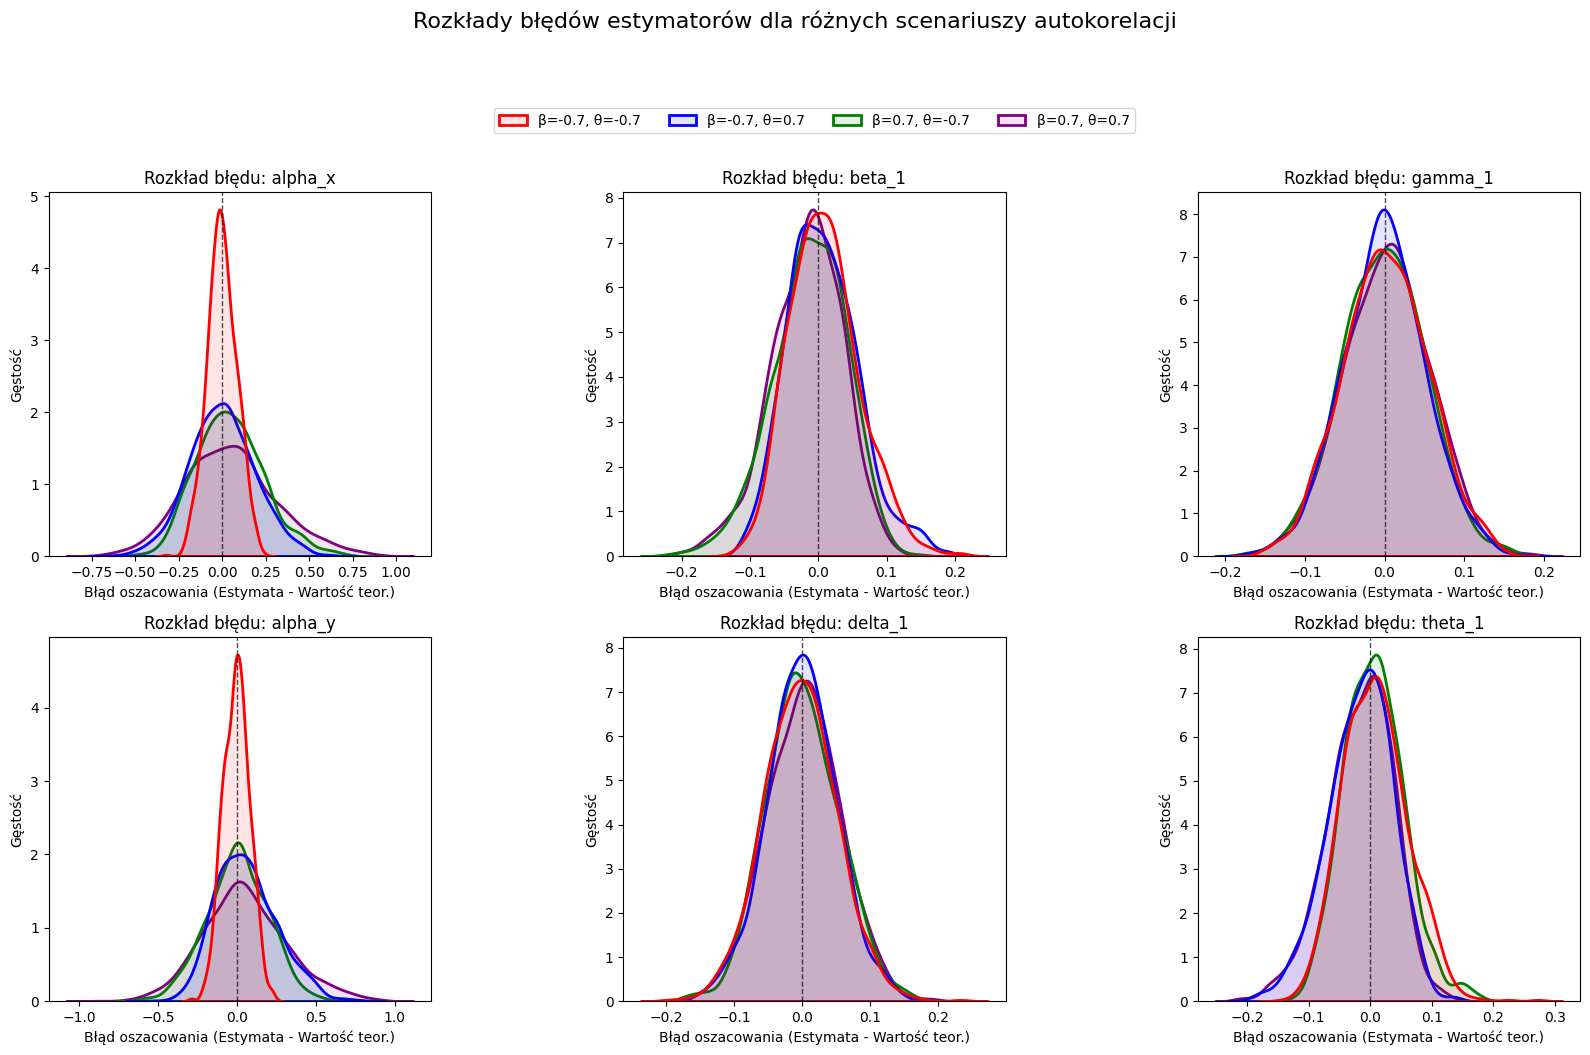

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Przygotowanie danych w formacie "Długim" (Long Format) dla Seaborn
# Pobieramy estymaty tylko dla jednego typu HC (np. 'classic'), bo dla innych są identyczne.
data_records = []

for (beta_true, theta_true), estimates in all_estimates.items():
    # estimates['classic'] to lista słowników z wynikami replikacji
    # iterujemy po każdej replikacji
    for record in estimates['classic']:
        # Obliczamy błąd (bias) dla każdego parametru
        bias_record = {
            "alpha_x": record["alpha_x"] - ALPHA_X,
            "beta_1":  record["beta_1"]  - beta_true,
            "gamma_1": record["gamma_1"] - GAMMA_1,
            "alpha_y": record["alpha_y"] - ALPHA_Y,
            "delta_1": record["delta_1"] - DELTA_1,
            "theta_1": record["theta_1"] - theta_true,
            # Dodajemy etykietę scenariusza do grupowania
            "Scenariusz": f"β={beta_true}, θ={theta_true}"
        }
        data_records.append(bias_record)

df_long = pd.DataFrame(data_records)

# 2. Rysowanie wykresów (Siatka 2x3)
# Używamy KDE (Kernel Density Estimation) zamiast histogramów dla lepszej czytelności przy nakładaniu
params = ["alpha_x", "beta_1", "gamma_1", "alpha_y", "delta_1", "theta_1"]
colors_palette = ["red", "blue", "green", "purple"] # Kolory odpowiadające Twoim poprzednim wykresom

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, param in enumerate(params):
    ax = axes[i]
    
    # Rysujemy rozkłady gęstości z podziałem na scenariusze (hue)
    sns.kdeplot(
        data=df_long,
        x=param,
        hue="Scenariusz",
        palette=colors_palette,
        fill=True,       # Wypełnienie kolorem pod wykresem
        alpha=0.1,       # Przezroczystość wypełnienia
        linewidth=2,     # Grubość linii
        ax=ax,
        common_norm=False # Każdy rozkład normowany osobno
    )
    
    # Dodajemy linię w zerze (oznacza brak obciążenia)
    ax.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)
    
    ax.set_title(f"Rozkład błędu: {param}", fontsize=12)
    ax.set_xlabel("Błąd oszacowania (Estymata - Wartość teor.)")
    ax.set_ylabel("Gęstość")
    
    # Usuwamy legendę z poszczególnych wykresów, żeby nie śmiecić
    # (zostawimy jedną wspólną lub tylko na pierwszym)
    if i != 1: 
        ax.get_legend().remove()
    else:
        # Przenosimy legendę na górę wykresu nr 2
        sns.move_legend(ax, "upper center", bbox_to_anchor=(0.5, 1.25), ncol=4, title=None)

plt.suptitle("Rozkłady błędów estymatorów dla różnych scenariuszy autokorelacji", y=1.05, fontsize=16)
plt.tight_layout()
plt.show()

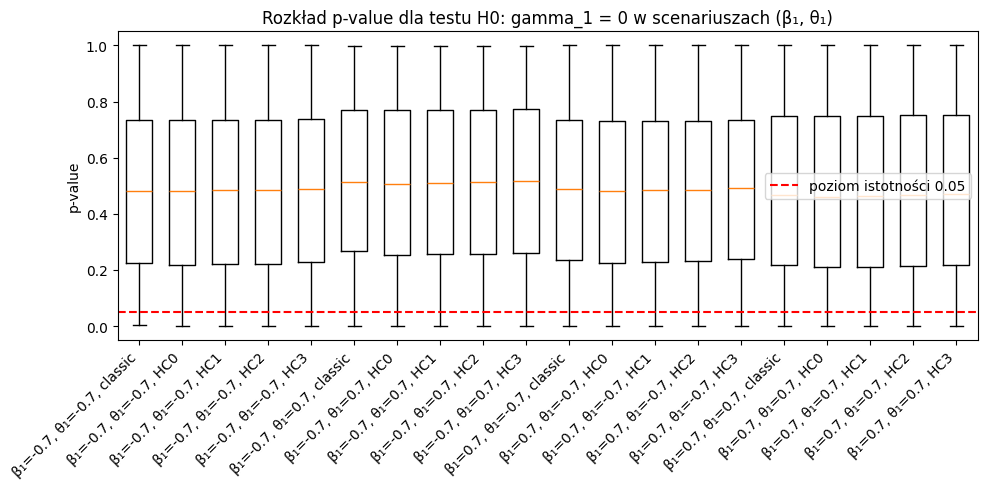

In [56]:
# Wykres 2: rozkład p-value dla gamma_1 (Y -> X) dla różnych estymatorów i scenariuszy (beta_1, theta_1)
rows = []
for beta_1, theta_1 in PARAM_GRID:
    pvalues = all_pvalues[(beta_1, theta_1)]
    for hc in HC_TYPES:
        df_pv = pd.DataFrame(pvalues[hc])
        tmp = pd.DataFrame(
            {"pvalue": df_pv["gamma_1"], "hc": hc, "beta_1": beta_1, "theta_1": theta_1}
        )
        rows.append(tmp)
pv_gamma_all = pd.concat(rows, ignore_index=True)

plt.figure(figsize=(10, 5))
positions = []
labels = []
current = 1
for beta_1, theta_1 in PARAM_GRID:
    for hc in HC_TYPES:
        mask = (pv_gamma_all["beta_1"] == beta_1) & (pv_gamma_all["theta_1"] == theta_1) & (pv_gamma_all["hc"] == hc)
        data = pv_gamma_all.loc[mask, "pvalue"]
        plt.boxplot(
            data,
            positions=[current],
            widths=0.6,
        )
        labels.append(f"β₁={beta_1}, θ₁={theta_1}, {hc}")
        positions.append(current)
        current += 1

plt.axhline(
    ALPHA,
    color="red",
    linestyle="--",
    label=f"poziom istotności {ALPHA}",
)
plt.xticks(positions, labels, rotation=45, ha="right")
plt.ylabel("p-value")
plt.title("Rozkład p-value dla testu H0: gamma_1 = 0 w scenariuszach (β₁, θ₁)")
plt.legend()
plt.tight_layout()
plt.show()


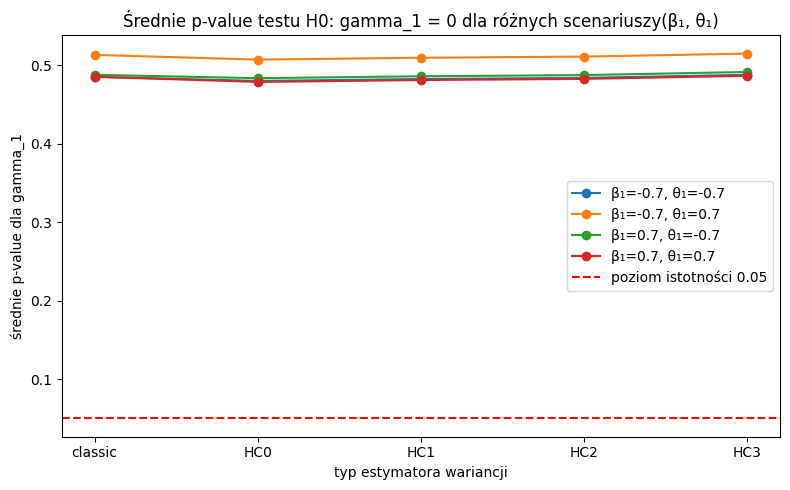

In [57]:
# Wykres 3: średnie p-value dla gamma_1 (Y -> X)
# dla różnych scenariuszy (β₁, θ₁) i estymatorów wariancji

rows_mean_pv = []
for beta_1, theta_1 in PARAM_GRID:
    pvalues = all_pvalues[(beta_1, theta_1)]
    for hc in HC_TYPES:
        df_pv = pd.DataFrame(pvalues[hc])
        mean_pv = df_pv["gamma_1"].mean()
        rows_mean_pv.append(
            {
                "beta_1": beta_1,
                "theta_1": theta_1,
                "hc": hc,
                "mean_pvalue": mean_pv,
            }
        )

mean_pv_gamma = pd.DataFrame(rows_mean_pv)

plt.figure(figsize=(8, 5))
x_positions = np.arange(len(HC_TYPES))
for beta_1, theta_1 in PARAM_GRID:
    subset = mean_pv_gamma[
        (mean_pv_gamma["beta_1"] == beta_1)
        & (mean_pv_gamma["theta_1"] == theta_1)
    ]
    y_values = [
        subset.loc[subset["hc"] == hc, "mean_pvalue"].values[0]
        for hc in HC_TYPES
    ]
    plt.plot(
        x_positions,
        y_values,
        marker="o",
        label=f"β₁={beta_1}, θ₁={theta_1}",
    )

plt.axhline(
    ALPHA,
    color="red",
    linestyle="--",
    label=f"poziom istotności {ALPHA}",
)
plt.xticks(x_positions, HC_TYPES)
plt.ylabel("średnie p-value dla gamma_1")
plt.xlabel("typ estymatora wariancji")
plt.title(
    "Średnie p-value testu H0: gamma_1 = 0 dla różnych scenariuszy(β₁, θ₁)"
)
plt.legend()
plt.tight_layout()
plt.show()


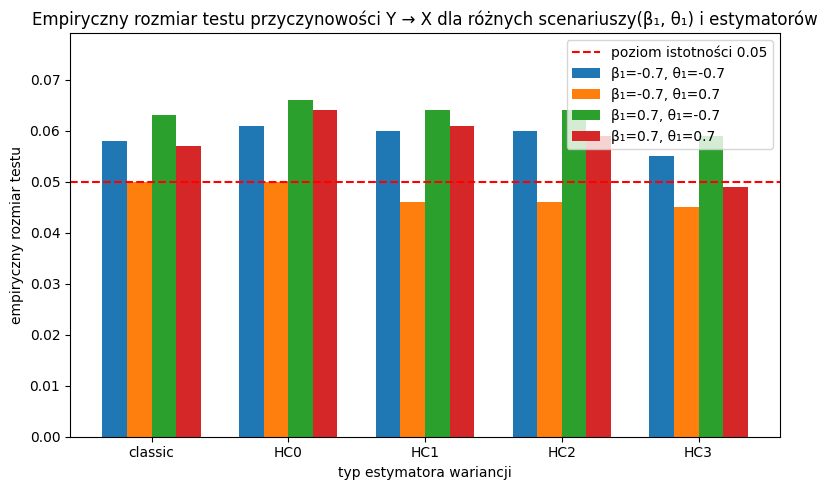

In [ ]:
# NIE UŻYWAMY TEGO DALEJ, BO TO JEST JUZ WYZEJ W FORMIE KROPKOWEJ

# Wykres 4: empiryczny rozmiar testu przyczynowości Y -> X (gamma_1 = 0)
# dla różnych scenariuszy (β₁, θ₁) i estymatorów wariancji

rows_sizes = []
for beta_1, theta_1 in PARAM_GRID:
    causality_rejects = all_causality_rejects[(beta_1, theta_1)]
    for hc in HC_TYPES:
        size = np.mean(causality_rejects[hc])
        rows_sizes.append(
            {
                "beta_1": beta_1,
                "theta_1": theta_1,
                "hc": hc,
                "size": size,
            }
        )

causality_sizes = pd.DataFrame(rows_sizes)

plt.figure(figsize=(8, 5))
index = np.arange(len(HC_TYPES))
bar_width = 0.18
n_scenarios = len(PARAM_GRID)

for i, (beta_1, theta_1) in enumerate(PARAM_GRID):
    subset = causality_sizes[
        (causality_sizes["beta_1"] == beta_1)
        & (causality_sizes["theta_1"] == theta_1)
    ]
    heights = [
        subset.loc[subset["hc"] == hc, "size"].values[0]
        for hc in HC_TYPES
    ]
    offset = (i - (n_scenarios - 1) / 2) * bar_width
    plt.bar(
        index + offset,
        heights,
        width=bar_width,
        label=f"β₁={beta_1}, θ₁={theta_1}",
    )

plt.axhline(
    ALPHA,
    color="red",
    linestyle="--",
    label=f"poziom istotności {ALPHA}",
)
plt.xticks(index, HC_TYPES)
plt.ylim(0.0, max(causality_sizes["size"].max(), ALPHA) * 1.2)
plt.ylabel("empiryczny rozmiar testu")
plt.xlabel("typ estymatora wariancji")
plt.title(
    "Empiryczny rozmiar testu przyczynowości Y → X dla różnych scenariuszy(β₁, θ₁) i estymatorów"
)
plt.legend()
plt.tight_layout()
plt.show()


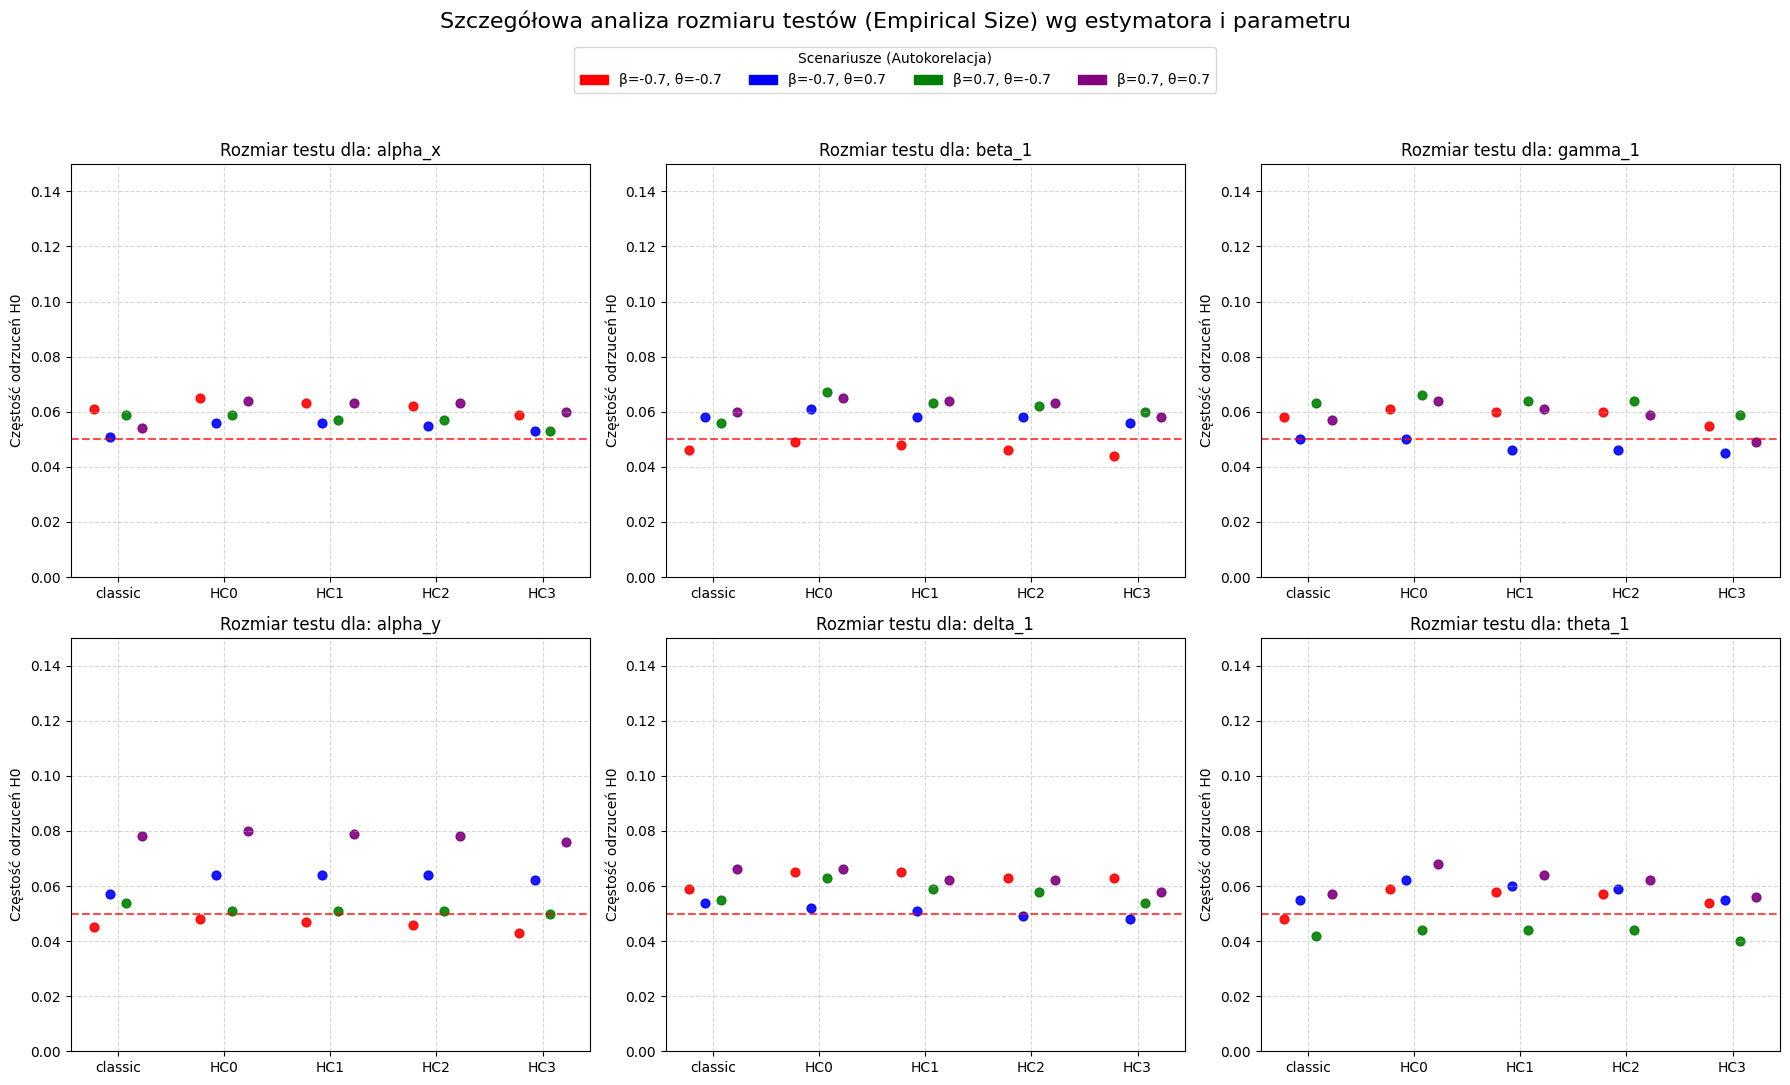

In [14]:
def plot_empirical_sizes_detailed(reject_df):
    """
    Rysuje szczegółowe rozmiary testów (bez uśredniania) dla każdego parametru osobno.
    Zastępuje błędny wykres słupkowy.
    """
    # Ustawienia siatki wykresów
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    # Parametry pomocnicze do wykresu
    x_base = np.arange(len(HC_TYPES))
    
    # Tworzenie legendy (uchwyty kolorów)
    legend_patches = [
        mpatches.Patch(color=color, label=f"β={b}, θ={t}")
        for (b, t), color in SCENARIO_COLORS.items()
    ]

    # Iteracja po parametrach (każdy parametr ma swoje okno)
    for i, param_name in enumerate(PARAMS_TO_PLOT):
        ax = axes[i]
        
        # Wyciągamy dane dla konkretnego parametru ze wszystkich scenariuszy.
        # Używamy level=-1 (bezpieczne odwołanie do nazwy parametru)
        try:
            subset = reject_df.xs(param_name, level=-1)
        except KeyError:
            print(f"Brak danych dla parametru: {param_name}")
            continue

        # Rysujemy punkty dla każdego scenariusza
        for j, (index_val, row) in enumerate(subset.iterrows()):
            # Bezpieczne rozpakowanie indeksu scenariusza (beta, theta)
            if isinstance(index_val, tuple):
                beta, theta = index_val[0], index_val[1]
            else:
                beta, theta = index_val

            # Pobranie koloru i obliczenie jittera (przesunięcia)
            color = SCENARIO_COLORS.get((float(beta), float(theta)), "black")
            offset = (j - 1.5) * OFFSET_STEP
            
            # Rysowanie punktów: Oś X = typ estymatora, Oś Y = rozmiar testu
            ax.scatter(
                x_base + offset, 
                row[HC_TYPES], 
                color=color, 
                s=40, 
                alpha=0.9,
                label=f"β={beta}, θ={theta}" if i == 0 else ""
            )

        # Linia pozioma dla poziomu istotności alpha = 0.05
        ax.axhline(ALPHA, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
        
        # Formatowanie osi
        ax.set_title(f"Rozmiar testu dla: {param_name}")
        ax.set_xticks(x_base)
        ax.set_xticklabels(HC_TYPES)
        # Ustawiamy zakres Y tak, by widzieć odchylenia, ale nie spłaszczać wykresu
        # (np. od 0 do 0.15, chyba że są ogromne błędy)
        ax.set_ylim(0.0, 0.15) 
        ax.set_ylabel("Częstość odrzuceń H0")
        ax.grid(True, linestyle='--', alpha=0.5)

    # Wspólna legenda
    fig.legend(
        handles=legend_patches, 
        loc='upper center', 
        bbox_to_anchor=(0.5, 1.05), 
        ncol=4, 
        title="Scenariusze (Autokorelacja)"
    )
    
    plt.suptitle("Szczegółowa analiza rozmiaru testów (Empirical Size) wg estymatora i parametru", y=1.08, fontsize=16)
    plt.tight_layout()
    plt.show()

# Uruchomienie (zamiast starego kodu z wykresem słupkowym)
plot_empirical_sizes_detailed(reject_all)

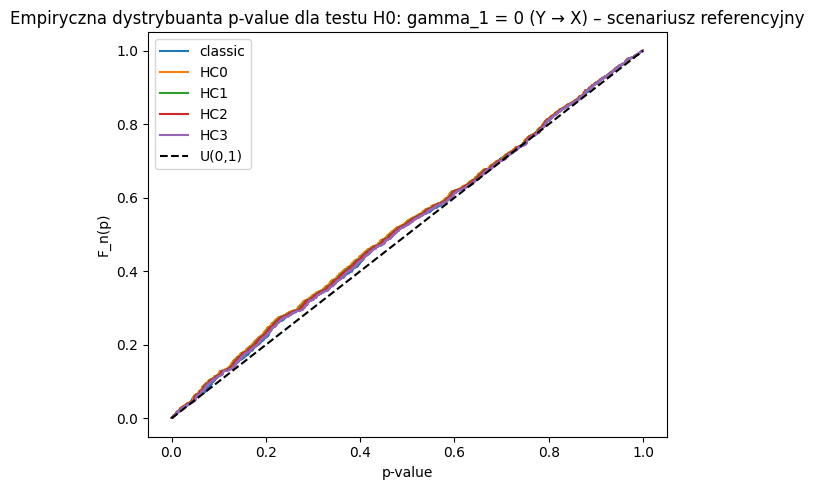

In [ ]:
#NIE UŻYWAMY W 5B

# Wykres 6: empiryczna dystrybuanta p-value dla testu H0: gamma_1 = 0 (Y → X) – wybrany scenariusz
# Dla czytelności wybieramy scenariusz referencyjny (BETA_1, THETA_1).
beta_ref, theta_ref = BETA_1, THETA_1
pvalues_ref = all_pvalues[(beta_ref, theta_ref)]
pvalues_df_ref = {hc: pd.DataFrame(records) for hc, records in pvalues_ref.items()}

plt.figure(figsize=(6, 5))
for hc in HC_TYPES:
    pvals = np.sort(pvalues_df_ref[hc]["gamma_1"].values)
    n = len(pvals)
    ecdf = np.arange(1, n + 1) / n
    plt.step(pvals, ecdf, where="post", label=hc)
# linia teoretyczna dla rozkładu jednostajnego U(0,1)
grid = np.linspace(0, 1, 200)
plt.plot(grid, grid, "k--", label="U(0,1)")
plt.xlabel("p-value")
plt.ylabel("F_n(p)")
plt.title("Empiryczna dystrybuanta p-value dla testu H0: gamma_1 = 0 (Y → X) – scenariusz referencyjny")
plt.legend()
plt.tight_layout()
plt.show()
